In [1]:
!pip install covid19dh

In [2]:
from covid19dh import covid19
x, src = covid19()

We have invested a lot of time and effort in creating COVID-19 Data Hub, please cite the following when using it:

	Guidotti, E., Ardia, D., (2020), "COVID-19 Data Hub", Journal of Open Source Software 5(51):2376, doi: 10.21105/joss.02376.

A BibTeX entry for LaTeX users is

	@Article{,
		title = {COVID-19 Data Hub},
		year = {2020},
		doi = {10.21105/joss.02376},
		author = {Emanuele Guidotti and David Ardia},
		journal = {Journal of Open Source Software},
		volume = {5},
		number = {51},
		pages = {2376},
	}

To hide this message use 'verbose = False'.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.express as px
import seaborn as sns

In [4]:
df=x
df

,id,date,confirmed,deaths,recovered,tests,vaccines,people_vaccinated,people_fully_vaccinated,hosp,...,iso_alpha_3,iso_alpha_2,iso_numeric,iso_currency,key_local,key_google_mobility,key_apple_mobility,key_jhu_csse,key_nuts,key_gadm
65898,0094b645,2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,LCA,LC,662.0,XCD,NaN,NaN,NaN,LC,NaN,LCA
65899,0094b645,2020-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,LCA,LC,662.0,XCD,NaN,NaN,NaN,LC,NaN,LCA
65900,0094b645,2020-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,LCA,LC,662.0,XCD,NaN,NaN,NaN,LC,NaN,LCA
65901,0094b645,2020-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,LCA,LC,662.0,XCD,NaN,NaN,NaN,LC,NaN,LCA
65902,0094b645,2020-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,LCA,LC,662.0,XCD,NaN,NaN,NaN,LC,NaN,LCA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24123,fd169ad6,2023-02-23,NaN,NaN,21285.0,NaN,NaN,NaN,NaN,NaN,...,LIE,LI,438.0,CHF,NaN,ChIJ_S9HHUQxm0cRibFa3Ta16mA,NaN,LI,NaN,LIE
24124,fd169ad6,2023-02-24,NaN,NaN,21286.0,NaN,NaN,NaN,NaN,NaN,...,LIE,LI,438.0,CHF,NaN,ChIJ_S9HHUQxm0cRibFa3Ta16mA,NaN,LI,NaN,LIE
24125,fd169ad6,2023-02-25,NaN,NaN,21288.0,NaN,NaN,NaN,NaN,NaN,...,LIE,LI,438.0,CHF,NaN,ChIJ_S9HHUQxm0cRibFa3Ta16mA,NaN,LI,NaN,LIE
24126,fd169ad6,2023-02-26,NaN,NaN,21293.0,NaN,NaN,NaN,NaN,NaN,...,LIE,LI,438.0,CHF,NaN,ChIJ_S9HHUQxm0cRibFa3Ta16mA,NaN,LI,NaN,LIE


In [5]:
df.columns

Index(['id', 'date', 'confirmed', 'deaths', 'recovered', 'tests', 'vaccines',
       'people_vaccinated', 'people_fully_vaccinated', 'hosp', 'icu', 'vent',
       'school_closing', 'workplace_closing', 'cancel_events',
       'gatherings_restrictions', 'transport_closing',
       'stay_home_restrictions', 'internal_movement_restrictions',
       'international_movement_restrictions', 'information_campaigns',
       'testing_policy', 'contact_tracing', 'facial_coverings',
       'vaccination_policy', 'elderly_people_protection',
       'government_response_index', 'stringency_index',
       'containment_health_index', 'economic_support_index',
       'administrative_area_level', 'administrative_area_level_1',
       'administrative_area_level_2', 'administrative_area_level_3',
       'latitude', 'longitude', 'population', 'iso_alpha_3', 'iso_alpha_2',
       'iso_numeric', 'iso_currency', 'key_local', 'key_google_mobility',
       'key_apple_mobility', 'key_jhu_csse', 'key_nuts', 'key_g

In [6]:
df=df.drop(['id','iso_alpha_2','iso_numeric','administrative_area_level_2','administrative_area_level_3','iso_currency','key_local',
            'key_google_mobility','key_apple_mobility', 'key_jhu_csse', 'key_nuts', 'key_gadm'],axis=1)

In [7]:
columns=df.columns
columns

Index(['date', 'confirmed', 'deaths', 'recovered', 'tests', 'vaccines',
       'people_vaccinated', 'people_fully_vaccinated', 'hosp', 'icu', 'vent',
       'school_closing', 'workplace_closing', 'cancel_events',
       'gatherings_restrictions', 'transport_closing',
       'stay_home_restrictions', 'internal_movement_restrictions',
       'international_movement_restrictions', 'information_campaigns',
       'testing_policy', 'contact_tracing', 'facial_coverings',
       'vaccination_policy', 'elderly_people_protection',
       'government_response_index', 'stringency_index',
       'containment_health_index', 'economic_support_index',
       'administrative_area_level', 'administrative_area_level_1', 'latitude',
       'longitude', 'population', 'iso_alpha_3'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 287783 entries, 65898 to 24127
Data columns (total 35 columns):
 #   Column                               Non-Null Count   Dtype         
---  ------                               --------------   -----         
 0   date                                 287783 non-null  datetime64[ns]
 1   confirmed                            239805 non-null  float64       
 2   deaths                               222577 non-null  float64       
 3   recovered                            74269 non-null   float64       
 4   tests                                88133 non-null   float64       
 5   vaccines                             70915 non-null   float64       
 6   people_vaccinated                    67602 non-null   float64       
 7   people_fully_vaccinated              65201 non-null   float64       
 8   hosp                                 46900 non-null   float64       
 9   icu                                  44785 non-null   float64       
 10

In [9]:
grouped=df.groupby('iso_alpha_3')
df_nan=pd.DataFrame()
nulls=grouped.apply(lambda x: x.isnull().sum().sum())
not_nulls=grouped.apply(lambda x: x.notnull().sum().sum())
df_nan['percent_of_missing [%]']=round(nulls/(nulls+not_nulls)*100,2)
df_nan=df_nan.sort_values(by='percent_of_missing [%]', ascending=True)
df_nan['all_missing']=grouped.apply(lambda x: x.isnull().sum().sum())
df_nan['rows_for_country']=grouped.size()
for col in df.columns:
    if col != 'iso_alpha_3':
        df_nan[f'{col}_missing'] = grouped[col].apply(lambda x: x.isnull().sum())
df_nan.reset_index(inplace=True)
df_nan.head(20)

/tmp/ipython-input-914/512164956.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nulls=grouped.apply(lambda x: x.isnull().sum().sum())
/tmp/ipython-input-914/512164956.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  not_nulls=grouped.apply(lambda x: x.notnull().sum().sum())
/tmp/ipython-input-914/512164956.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavi

,iso_alpha_3,percent_of_missing [%],all_missing,rows_for_country,date_missing,confirmed_missing,deaths_missing,recovered_missing,tests_missing,vaccines_missing,...,elderly_people_protection_missing,government_response_index_missing,stringency_index_missing,containment_health_index_missing,economic_support_index_missing,administrative_area_level_missing,administrative_area_level_1_missing,latitude_missing,longitude_missing,population_missing
0,LTU,1.31,378,824,0,0,0,0,0,0,...,21,21,21,21,21,0,0,0,0,0
1,PER,4.02,952,677,0,1,13,11,33,202,...,2,27,27,27,1,0,0,0,0,0
2,CHL,5.01,1869,1066,0,0,19,118,37,304,...,32,32,32,32,32,0,0,0,0,0
3,PRT,9.03,2559,810,0,54,54,65,4,441,...,0,0,0,0,0,0,0,0,0,0
4,EST,9.11,3198,1003,0,38,65,536,151,355,...,14,14,14,14,14,0,0,0,0,0
5,SGP,11.46,2931,731,0,1,59,215,646,347,...,4,4,4,4,4,0,0,0,0,0
6,SVN,11.51,3615,897,0,169,169,484,169,358,...,17,17,17,17,17,0,0,0,0,0
7,DNK,12.79,5305,1185,0,78,94,715,329,357,...,91,91,91,91,91,0,0,0,0,0
8,JPN,12.98,5375,1183,0,0,6,224,224,372,...,128,128,128,128,128,0,0,0,0,0
9,BGR,13.04,4985,1092,0,46,49,602,561,398,...,36,37,37,37,36,0,0,0,0,0


In [10]:
missing_elemnts=df.isnull().sum().sum()
total_elements=df.size
print(f'Missing values: {missing_elemnts}, Total values count: {total_elements}, Percentage of missing values: {missing_elemnts/total_elements*100:.2f} %')

Missing values: 3580523, Total values count: 10072405, Percentage of missing values: 35.55 %


In [11]:
df_tests=df.copy()
df_tests=df_tests[['iso_alpha_3','tests','population']]
df_tests['tests'].astype('float')
df_tests['population'].astype('float')
df_tests=df_tests.groupby('iso_alpha_3').agg({ 'tests': 'max', 'population': 'mean' })
df_tests.reset_index()
df_tests['tests_per_person']=df_tests['tests']/df_tests['population']
df_tests=df_tests.sort_values('tests_per_person', ascending=False)
df_tests.head(10)

,tests,population,tests_per_person
iso_alpha_3,,,
CYP,29501771.0,1189265.0,24.806726
AUT,207903030.0,8840521.0,23.517056
ARE,168522672.0,9630959.0,17.498016
FRO,777845.0,48497.0,16.039033
GIB,533268.0,33718.0,15.815529
DNK,64649913.0,5793636.0,11.158781
SVK,51238482.0,5446771.0,9.407130
SVN,17197882.0,2073894.0,8.292556
GRC,84483362.0,10731726.0,7.872300


In [12]:
df.describe()

,date,confirmed,deaths,recovered,tests,vaccines,people_vaccinated,people_fully_vaccinated,hosp,icu,...,vaccination_policy,elderly_people_protection,government_response_index,stringency_index,containment_health_index,economic_support_index,administrative_area_level,latitude,longitude,population
count,287783,2.398050e+05,2.225770e+05,7.426900e+04,8.813300e+04,7.091500e+04,6.760200e+04,6.520100e+04,4.690000e+04,44785.000000,...,198187.000000,197829.000000,197826.000000,197828.000000,197826.000000,197833.000000,287783.0,282737.000000,282737.000000,2.866210e+05
mean,2021-10-08 02:12:59.412265984,1.528542e+06,1.975965e+04,1.201758e+06,2.537975e+07,9.022673e+07,3.292277e+07,2.947400e+07,7.602315e+03,608.878732,...,2.708851,0.684677,46.255100,44.824160,48.219631,32.502477,1.0,17.497552,15.337292,3.719120e+07
min,2020-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,...,0.000000,-3.000000,0.000000,0.000000,0.000000,0.000000,1.0,-51.750000,-176.200000,5.000000e+01
25%,2020-11-19 00:00:00,5.587000e+03,1.060000e+02,3.427000e+03,3.994000e+05,6.214110e+05,3.683700e+05,2.692030e+05,1.040000e+02,14.000000,...,0.000000,0.000000,33.120000,24.070000,35.120000,0.000000,1.0,3.202800,-24.000000,5.759910e+05
50%,2021-09-27 00:00:00,4.760800e+04,8.780000e+02,3.400000e+04,2.216971e+06,6.776351e+06,3.610188e+06,3.110890e+06,6.200000e+02,65.000000,...,4.000000,1.000000,48.440000,46.300000,50.950000,25.000000,1.0,16.750000,18.732200,6.322800e+06
75%,2022-08-06 00:00:00,4.401840e+05,7.553000e+03,2.949940e+05,1.262730e+07,3.342240e+07,1.528476e+07,1.356295e+07,2.887250e+03,391.000000,...,5.000000,2.000000,61.460000,64.350000,63.330000,62.500000,1.0,39.000000,48.516388,2.360305e+07
max,2024-10-19 00:00:00,1.039100e+08,1.135343e+06,3.778816e+07,9.214000e+09,3.491077e+09,1.310292e+09,1.276760e+09,1.993062e+06,28891.000000,...,5.000000,3.000000,91.150000,100.000000,93.450000,100.000000,1.0,64.963100,178.065000,1.392730e+09
std,NaN,6.990292e+06,7.761699e+04,4.407888e+06,8.660879e+07,3.647408e+08,1.289587e+08,1.176855e+08,6.625832e+04,2017.363592,...,2.286168,1.340879,19.506705,24.707207,19.747202,32.947569,0.0,24.235357,72.606977,1.472837e+08


In [13]:
src[src['data_type'].isin(['tests'])]

,iso_alpha_3,administrative_area_level,data_type,url,title,year,bibtype,author,institution,textVersion
744,ABW,1,tests,https://github.com/owid/covid-19-data,Our World in Data,2020,NaN,NaN,NaN,NaN
744,AFG,1,tests,https://github.com/owid/covid-19-data,Our World in Data,2020,NaN,NaN,NaN,NaN
744,AGO,1,tests,https://github.com/owid/covid-19-data,Our World in Data,2020,NaN,NaN,NaN,NaN
744,AIA,1,tests,https://github.com/owid/covid-19-data,Our World in Data,2020,NaN,NaN,NaN,NaN
744,ALB,1,tests,https://github.com/owid/covid-19-data,Our World in Data,2020,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
744,VUT,1,tests,https://github.com/owid/covid-19-data,Our World in Data,2020,NaN,NaN,NaN,NaN
744,YEM,1,tests,https://github.com/owid/covid-19-data,Our World in Data,2020,NaN,NaN,NaN,NaN
733,ZAF,1,tests,https://github.com/dsfsi/covid19za,"Data Science for Social Impact research group,...",2020,NaN,NaN,NaN,NaN
744,ZMB,1,tests,https://github.com/owid/covid-19-data,Our World in Data,2020,NaN,NaN,NaN,NaN


In [14]:
df.columns

Index(['date', 'confirmed', 'deaths', 'recovered', 'tests', 'vaccines',
       'people_vaccinated', 'people_fully_vaccinated', 'hosp', 'icu', 'vent',
       'school_closing', 'workplace_closing', 'cancel_events',
       'gatherings_restrictions', 'transport_closing',
       'stay_home_restrictions', 'internal_movement_restrictions',
       'international_movement_restrictions', 'information_campaigns',
       'testing_policy', 'contact_tracing', 'facial_coverings',
       'vaccination_policy', 'elderly_people_protection',
       'government_response_index', 'stringency_index',
       'containment_health_index', 'economic_support_index',
       'administrative_area_level', 'administrative_area_level_1', 'latitude',
       'longitude', 'population', 'iso_alpha_3'],
      dtype='object')

In [15]:
df_denmark=df[df['iso_alpha_3']=='DNK']
df_denmark

,date,confirmed,deaths,recovered,tests,vaccines,people_vaccinated,people_fully_vaccinated,hosp,icu,...,government_response_index,stringency_index,containment_health_index,economic_support_index,administrative_area_level,administrative_area_level_1,latitude,longitude,population,iso_alpha_3
115921,2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,1,Denmark,56.26,9.5,5793636.0,DNK
115922,2020-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,1,Denmark,56.26,9.5,5793636.0,DNK
115923,2020-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,1,Denmark,56.26,9.5,5793636.0,DNK
115924,2020-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,1,Denmark,56.26,9.5,5793636.0,DNK
115925,2020-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,1,Denmark,56.26,9.5,5793636.0,DNK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117101,2023-03-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,347.0,11.0,...,NaN,NaN,NaN,NaN,1,Denmark,56.26,9.5,5793636.0,DNK
117102,2023-03-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0,...,NaN,NaN,NaN,NaN,1,Denmark,56.26,9.5,5793636.0,DNK
117103,2023-03-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,...,NaN,NaN,NaN,NaN,1,Denmark,56.26,9.5,5793636.0,DNK
117104,2023-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,...,NaN,NaN,NaN,NaN,1,Denmark,56.26,9.5,5793636.0,DNK


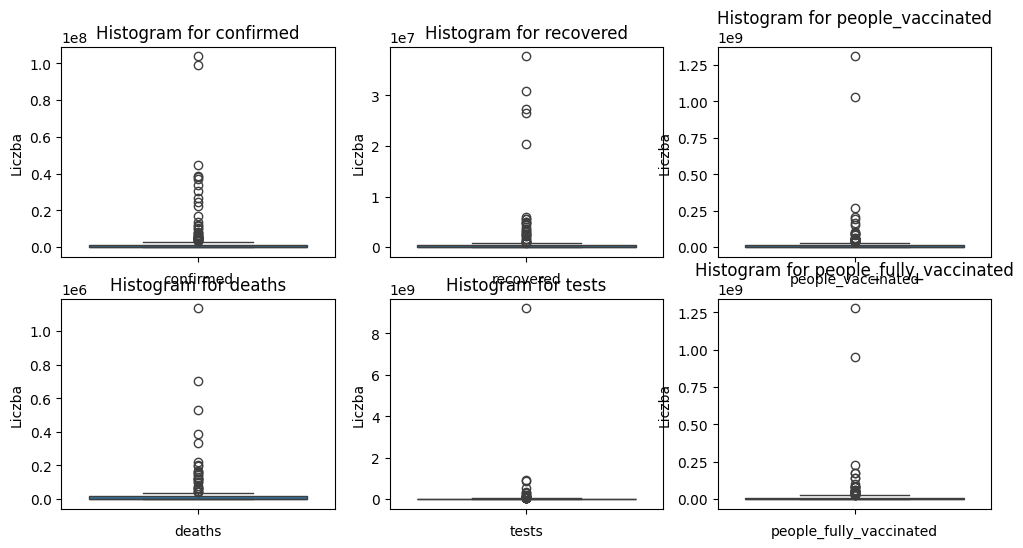

In [16]:
features = ['confirmed', 'deaths', 'recovered', 'tests', 'people_vaccinated', 'people_fully_vaccinated']
df_grouped=df.groupby('iso_alpha_3').agg({ 'confirmed': 'max',
                                         'deaths': 'max',
                                         'recovered': 'max',
                                         'tests': 'max',
                                         'people_vaccinated': 'max',
                                         'people_fully_vaccinated': 'max',
                                         'population': 'mean',
                                         })
fig,ax=plt.subplots(2,3,figsize=(12, 6))

#for i in range(len(features)):
#    sns.histplot(df_grouped[features[i]].dropna(), bins=30, kde=True, ax=ax[i%2,i//2])
#    ax[i%2,i//2].set_title(f'Histogram dla {features[i]}')
#    ax[i%2,i//2].set_xlabel(features[i])
#    ax[i%2,i//2].set_ylabel('Liczba')

for i in range(len(features)):
    sns.boxplot(df_grouped[features[i]].dropna(), ax=ax[i%2,i//2])
    ax[i%2,i//2].set_title(f'Histogram for {features[i]}')
    ax[i%2,i//2].set_xlabel(features[i])
    ax[i%2,i//2].set_ylabel('Liczba')

plt.show()

In [17]:
european_countries=['ALB', 'AND', 'AUT', 'BLR', 'BEL', 'BIH', 'BGR', 'HRV', 'CYP', 'CZE', 'DNK', 'EST', 'FIN',
                    'FRA', 'DEU', 'GRC', 'HUN', 'ISL', 'IRL', 'ITA', 'XKX', 'LVA', 'LIE', 'LTU', 'LUX', 'MLT',
                    'MDA', 'MCO', 'MNE', 'NLD', 'MKD', 'NOR', 'POL', 'PRT', 'ROU', 'RUS', 'SMR', 'SRB', 'SVK',
                    'SVN', 'ESP', 'SWE', 'CHE', 'UKR', 'GBR']

In [18]:
df_new=pd.DataFrame()
df_stats=df[['confirmed', 'deaths', 'recovered', 'tests', 'vaccines',
       'people_vaccinated', 'people_fully_vaccinated','population','iso_alpha_3']]
df_stats=df_stats.groupby('iso_alpha_3').agg({ 'confirmed': 'max',
                                         'deaths': 'max',
                                         'recovered': 'max',
                                         'tests': 'max',
                                         'people_vaccinated': 'max',
                                         'people_fully_vaccinated': 'max',
                                         'population': 'mean',
                                         })
df_stats['percent_of_people_vaccinated [%]']=df_stats['people_vaccinated']/df_stats['population']*100
df_stats=df_stats.sort_values(by='percent_of_people_vaccinated [%]',ascending=False)
df_stats=df_stats.reset_index()
df_stats_temp=df_stats[['iso_alpha_3','people_vaccinated','population','percent_of_people_vaccinated [%]']]
df_stats_temp.head(20)
iso_alpha_3_delete=['COK','TKL','GIB','MAC','BRN','ARE','NRU','QAT']


In [19]:
df_new=pd.DataFrame()
df_stats=df[['confirmed', 'deaths', 'recovered', 'tests', 'vaccines',
       'people_vaccinated', 'people_fully_vaccinated','population','iso_alpha_3']]
df_stats=df_stats.groupby('iso_alpha_3').agg({ 'confirmed': 'max',
                                         'deaths': 'max',
                                         'recovered': 'max',
                                         'tests': 'max',
                                         'people_vaccinated': 'max',
                                         'people_fully_vaccinated': 'max',
                                         'population': 'mean',
                                         })

df_stats['percent_of_confirmed [%]']=round(df_stats['confirmed']/df_stats['population']*100,2)
df_stats['percent_of_deaths [%]']=round(df_stats['deaths']/df_stats['population']*100,2)
df_stats['percent_of_recovered [%]']=round(df_stats['recovered']/df_stats['population']*100,2)
df_stats['tests_per_person']=round(df_stats['tests']/df_stats['population'],2)
df_stats['percent_of_people_vaccinated [%]']=round(df_stats['people_vaccinated']/df_stats['population']*100,2)
df_stats['percent_of_people_fully_vaccinated [%]']=round(df_stats['people_fully_vaccinated']/df_stats['population']*100,2)

df_stats=df_stats.reset_index()
df_stats_denmark=df_stats[df_stats['iso_alpha_3']=='DNK']
df_stats_europe=df_stats[df_stats['iso_alpha_3'].isin(european_countries)]
df_stats_world=df_stats
median_europe = df_stats_europe.median(numeric_only=True)
median_world = df_stats_world.median(numeric_only=True)

regions=['Denmark', 'Europe', 'World']

df_stats_compare = pd.DataFrame({
    'Region': regions,
    'percent_of_confirmed [%]': [df_stats_denmark['percent_of_confirmed [%]'].values[0], median_europe['percent_of_confirmed [%]'], median_world['percent_of_confirmed [%]']],
    'percent_of_deaths [%]': [df_stats_denmark['percent_of_deaths [%]'].values[0], median_europe['percent_of_deaths [%]'], median_world['percent_of_deaths [%]']],
    'percent_of_recovered [%]': [df_stats_denmark['percent_of_recovered [%]'].values[0], median_europe['percent_of_recovered [%]'], median_world['percent_of_recovered [%]']],
    'tests_per_person': [df_stats_denmark['tests_per_person'].values[0], median_europe['tests_per_person'], median_world['tests_per_person']],
    'percent_of_people_vaccinated [%]': [df_stats_denmark['percent_of_people_vaccinated [%]'].values[0], median_europe['percent_of_people_vaccinated [%]'], median_world['percent_of_people_vaccinated [%]']],
    'percent_of_people_fully_vaccinated [%]': [df_stats_denmark['percent_of_people_fully_vaccinated [%]'].values[0], median_europe['percent_of_people_fully_vaccinated [%]'], median_world['percent_of_people_fully_vaccinated [%]']]
})
df_stats_compare

,Region,percent_of_confirmed [%],percent_of_deaths [%],percent_of_recovered [%],tests_per_person,percent_of_people_vaccinated [%],percent_of_people_fully_vaccinated [%]
0,Denmark,58.76,0.14,5.29,11.16,82.53,81.92
1,Europe,41.84,0.26,6.20,2.59,71.11,68.60
2,World,13.66,0.10,1.62,0.63,69.38,63.95


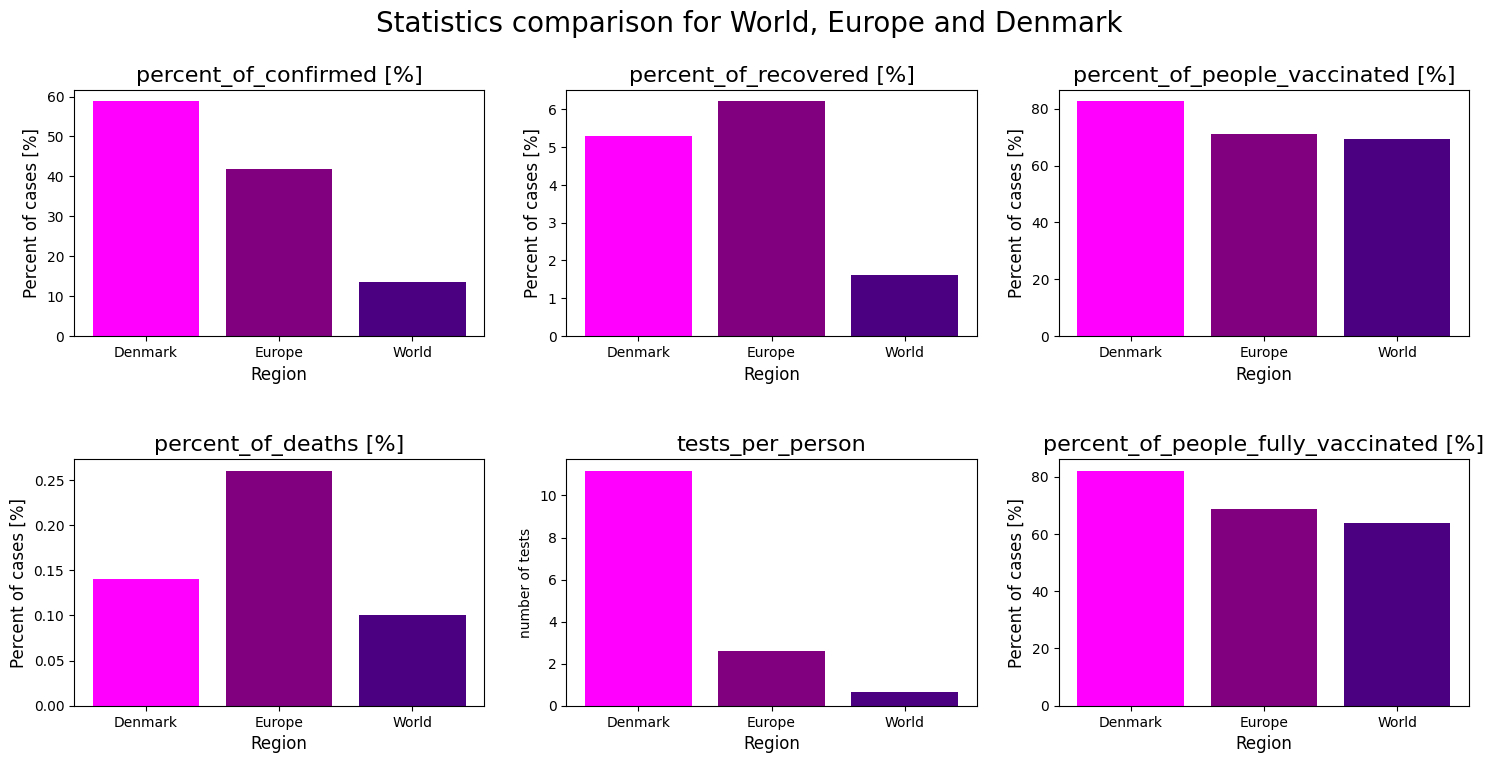

In [20]:
colors=['magenta','purple','indigo']
fig,ax=plt.subplots(2,3,figsize=(18,8))
plt.suptitle('Statistics comparison for World, Europe and Denmark', fontsize=20)
plt.subplots_adjust(hspace=0.5)
for i in range(len(df_stats_compare.columns)-1):
  ax[i%2,i//2].bar(regions,df_stats_compare[df_stats_compare.columns[i+1]],color=colors)
  ax[i%2,i//2].set_title(f'{df_stats_compare.columns[i+1]}',fontsize=16)
  if i == 3:
    ax[i%2,i//2].set_ylabel('number of tests')
  else:
    ax[i%2,i//2].set_ylabel('Percent of cases [%]',fontsize=12)
  ax[i%2,i//2].set_xlabel('Region',fontsize=12)

In [21]:
df.columns

Index(['date', 'confirmed', 'deaths', 'recovered', 'tests', 'vaccines',
       'people_vaccinated', 'people_fully_vaccinated', 'hosp', 'icu', 'vent',
       'school_closing', 'workplace_closing', 'cancel_events',
       'gatherings_restrictions', 'transport_closing',
       'stay_home_restrictions', 'internal_movement_restrictions',
       'international_movement_restrictions', 'information_campaigns',
       'testing_policy', 'contact_tracing', 'facial_coverings',
       'vaccination_policy', 'elderly_people_protection',
       'government_response_index', 'stringency_index',
       'containment_health_index', 'economic_support_index',
       'administrative_area_level', 'administrative_area_level_1', 'latitude',
       'longitude', 'population', 'iso_alpha_3'],
      dtype='object')

In [22]:
stats_2_columns=['school_closing', 'workplace_closing', 'cancel_events',
                   'gatherings_restrictions', 'transport_closing',
                   'stay_home_restrictions', 'internal_movement_restrictions',
                   'international_movement_restrictions', 'information_campaigns',
                   'testing_policy', 'contact_tracing', 'facial_coverings',
                   'vaccination_policy', 'elderly_people_protection',
                   'government_response_index', 'stringency_index',
                   'containment_health_index', 'economic_support_index', 'iso_alpha_3']

df_stats_2=df[stats_2_columns]

df_stats_2[df_stats_2.columns.difference(['iso_alpha_3'])]=df_stats_2[df_stats_2.columns.difference(['iso_alpha_3'])].abs()

df_stats_2=df_stats_2.groupby('iso_alpha_3').mean().reset_index()

df_stats_2

/tmp/ipython-input-914/3409317475.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_stats_2[df_stats_2.columns.difference(['iso_alpha_3'])]=df_stats_2[df_stats_2.columns.difference(['iso_alpha_3'])].abs()


,iso_alpha_3,school_closing,workplace_closing,cancel_events,gatherings_restrictions,transport_closing,stay_home_restrictions,internal_movement_restrictions,international_movement_restrictions,information_campaigns,testing_policy,contact_tracing,facial_coverings,vaccination_policy,elderly_people_protection,government_response_index,stringency_index,containment_health_index,economic_support_index
0,ABW,0.853955,0.991886,1.359026,2.542596,0.000000,0.803245,0.238337,1.507099,1.886410,0.916836,1.313387,1.797160,2.782961,1.049696,40.592414,40.415406,42.524817,27.053753
1,AFG,0.932234,1.491758,1.087912,0.641026,0.670330,0.322344,0.338828,1.362637,0.692308,0.645604,0.362637,2.233516,1.508242,0.523810,24.414707,27.494927,27.801328,0.709707
2,AGO,0.815934,1.882784,1.172161,2.186813,0.616300,0.912088,1.304945,2.665751,1.746337,2.054945,0.280220,2.785714,2.767399,0.415751,44.668526,51.914643,49.185375,13.049451
3,AIA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ALB,1.289762,1.065814,1.131627,2.454296,0.277879,1.166362,0.329068,1.181901,1.726691,1.894881,0.909506,2.319013,2.659963,1.506399,45.027450,42.123921,46.367660,35.648995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
228,WSM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
229,YEM,0.822344,0.641026,0.806777,0.000000,0.000000,1.248168,0.588828,1.952381,0.820513,0.749084,0.317766,0.709707,1.913919,0.516484,21.702125,26.428324,24.802940,0.000000
230,ZAF,0.986289,1.236746,1.044790,2.125229,0.639854,1.139854,0.407678,1.467093,1.886654,2.659963,1.592322,2.088665,2.642596,1.523766,51.312468,44.474680,51.744461,48.286106
231,ZMB,0.798903,0.751371,0.851005,2.007313,0.052102,0.134369,0.120658,1.418647,1.533821,1.976234,0.694698,2.708410,2.388483,0.081353,32.695420,29.757459,34.758656,18.258684


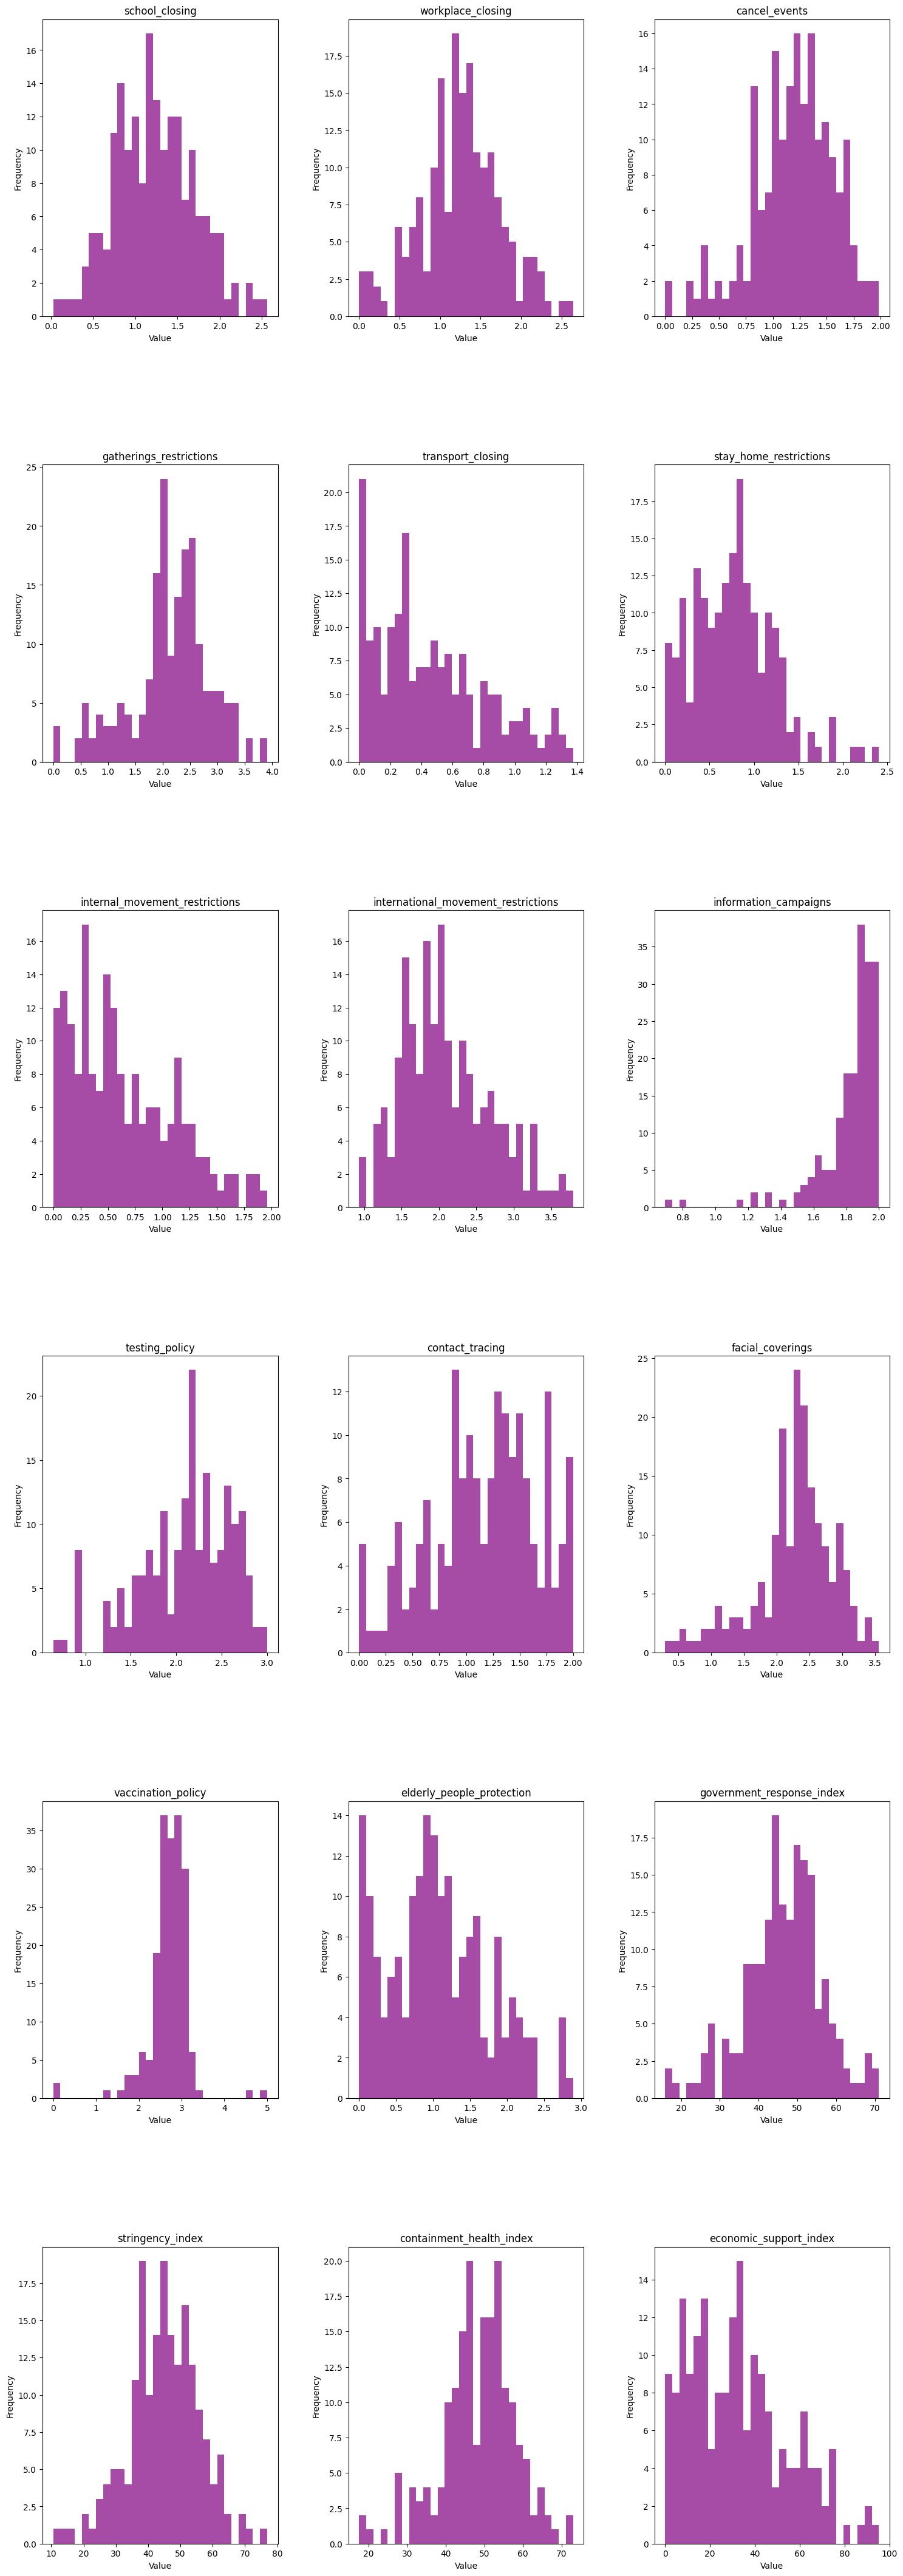

In [23]:
data_to_plot = df_stats_2.drop(columns=['iso_alpha_3'])

num_vars = data_to_plot.shape[1]
fig, axes = plt.subplots(nrows=num_vars//3 + (num_vars % 3 > 0), ncols=3, figsize=(18, num_vars * 3))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
axes = axes.flatten()
for i, col in enumerate(data_to_plot.columns):
    ax = axes[i]
    ax.hist(data_to_plot[col], bins=30, color='purple', alpha=0.7)
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

/tmp/ipython-input-914/503462356.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0,0].set_xticklabels(ax[0,0].get_xticklabels(), rotation=90)
/tmp/ipython-input-914/503462356.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0,1].set_xticklabels(ax[0,1].get_xticklabels(), rotation=90)
/tmp/ipython-input-914/503462356.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1,0].set_xticklabels(ax[1,0].get_xticklabels(), rotation=90)
/tmp/ipython-input-914/503462356.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1,1].set_xticklabels(ax[1,1].get_xticklabels(), rotation=90)
/tmp/ipython-input-914/503462356.py:50: UserWarning: set_ticklab

Text(0.5, 0, 'Variable')

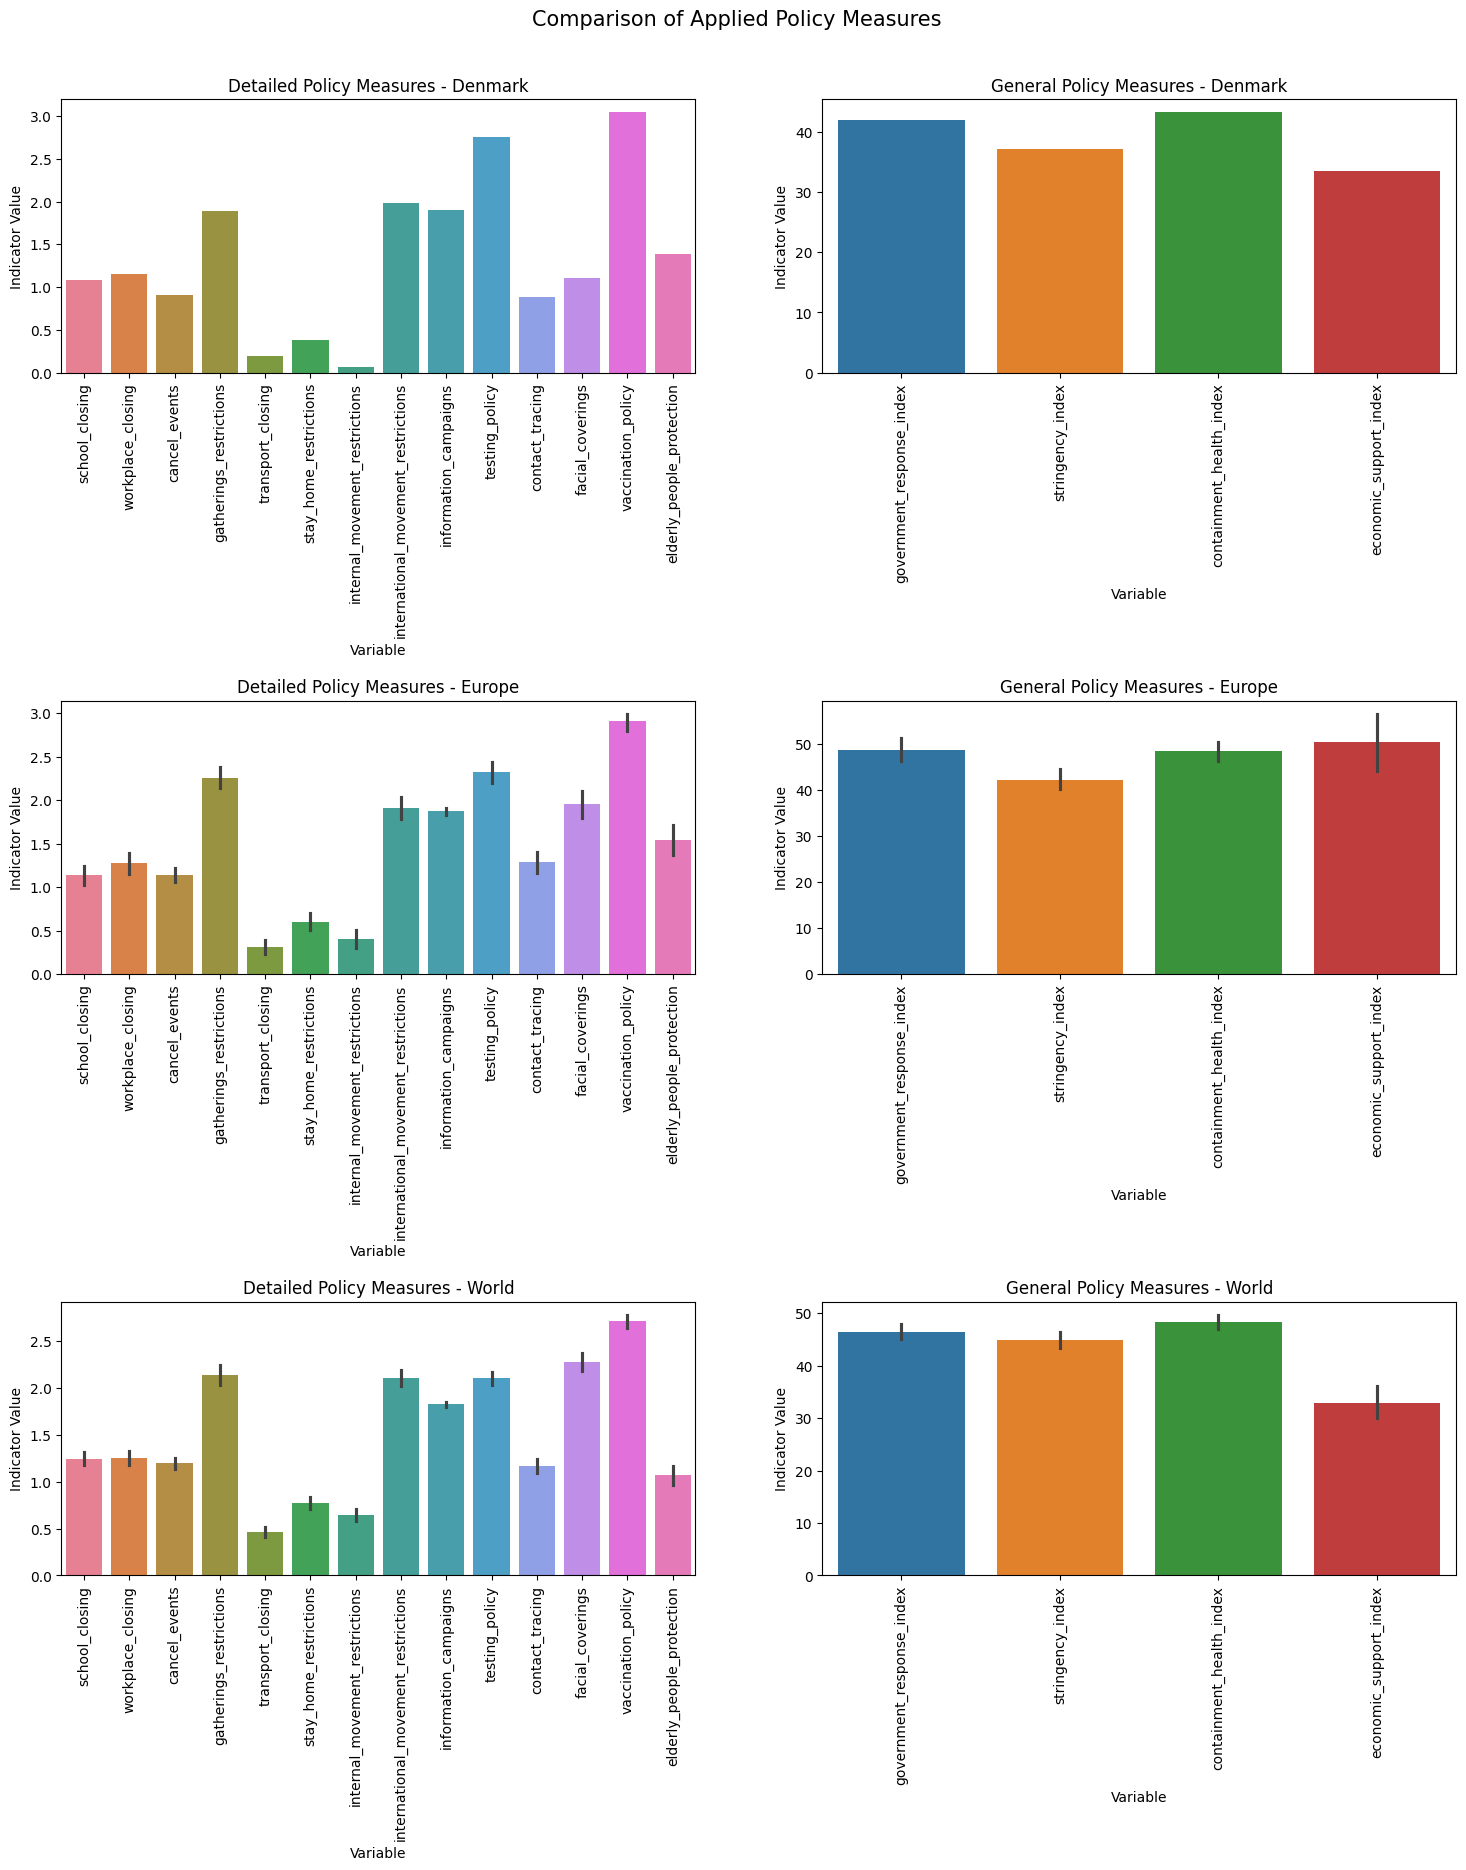

In [24]:
specific_columns=['school_closing', 'workplace_closing', 'cancel_events',
                   'gatherings_restrictions', 'transport_closing',
                   'stay_home_restrictions', 'internal_movement_restrictions',
                   'international_movement_restrictions', 'information_campaigns',
                   'testing_policy', 'contact_tracing', 'facial_coverings',
                   'vaccination_policy', 'elderly_people_protection']
general_columns=['government_response_index', 'stringency_index',
                   'containment_health_index', 'economic_support_index']
df_stats_2_denmark=df_stats_2[df_stats['iso_alpha_3']=='DNK']
df_stats_2_denmark_spec=df_stats_2_denmark[specific_columns]
df_stats_2_denmark_gen=df_stats_2_denmark[general_columns]
df_stats_2_europe=df_stats_2[df_stats_2['iso_alpha_3'].isin(european_countries)]
df_stats_2_europe_spec=df_stats_2_europe[specific_columns]
df_stats_2_europe_gen=df_stats_2_europe[general_columns]
df_stats_2_world=df_stats_2
df_stats_2_world_spec=df_stats_2_world[specific_columns]
df_stats_2_world_gen=df_stats_2_world[general_columns]

regions=['Denmark', 'Europe', 'World']
df_stats_2_denmark=df_stats_2_denmark.drop('iso_alpha_3',axis=1)
fig,ax=plt.subplots(3,2,figsize=(18,18))
plt.suptitle('Comparison of Applied Policy Measures', fontsize=15)
plt.subplots_adjust(hspace=1.2, top=0.93)

sns.barplot(df_stats_2_denmark_spec, ax=ax[0,0])
ax[0,0].set_xticklabels(ax[0,0].get_xticklabels(), rotation=90)
ax[0,0].set_title('Detailed Policy Measures - Denmark')
ax[0,0].set_ylabel('Indicator Value')
ax[0,0].set_xlabel('Variable')

sns.barplot(df_stats_2_denmark_gen, ax=ax[0,1])
ax[0,1].set_xticklabels(ax[0,1].get_xticklabels(), rotation=90)
ax[0,1].set_title('General Policy Measures - Denmark')
ax[0,1].set_ylabel('Indicator Value')
ax[0,1].set_xlabel('Variable')

sns.barplot(df_stats_2_europe_spec, ax=ax[1,0])
ax[1,0].set_xticklabels(ax[1,0].get_xticklabels(), rotation=90)
ax[1,0].set_title('Detailed Policy Measures - Europe')
ax[1,0].set_ylabel('Indicator Value')
ax[1,0].set_xlabel('Variable')

sns.barplot(df_stats_2_europe_gen, ax=ax[1,1])
ax[1,1].set_xticklabels(ax[1,1].get_xticklabels(), rotation=90)
ax[1,1].set_title('General Policy Measures - Europe')
ax[1,1].set_ylabel('Indicator Value')
ax[1,1].set_xlabel('Variable')

sns.barplot(df_stats_2_world_spec, ax=ax[2,0])
ax[2,0].set_xticklabels(ax[2,0].get_xticklabels(), rotation=90)
ax[2,0].set_title('Detailed Policy Measures - World')
ax[2,0].set_ylabel('Indicator Value')
ax[2,0].set_xlabel('Variable')

sns.barplot(df_stats_2_world_gen, ax=ax[2,1])
ax[2,1].set_xticklabels(ax[2,1].get_xticklabels(), rotation=90)
ax[2,1].set_title('General Policy Measures - World')
ax[2,1].set_ylabel('Indicator Value')
ax[2,1].set_xlabel('Variable')

In [25]:
df_stats['percent_of_confirmed [%]']=round(df_stats['confirmed']/df_stats['population']*100,2)
df_stats['percent_of_deaths [%]']=round(df_stats['deaths']/df_stats['population']*100,2)
df_stats['percent_of_recovered [%]']=round(df_stats['recovered']/df_stats['population']*100,2)
df_stats['tests_per_person']=round(df_stats['tests']/df_stats['population'],2)
df_stats['percent_of_people_vaccinated [%]']=round(df_stats['people_vaccinated']/df_stats['population']*100,2)
df_stats['percent_of_people_fully_vaccinated [%]']=round(df_stats['people_fully_vaccinated']/df_stats['population']*100,2)

df_stats=df_stats.reset_index()
df_stats_denmark=df_stats[df_stats['iso_alpha_3']=='DNK']
df_stats_europe=df_stats[df_stats['iso_alpha_3'].isin(european_countries)]
df_stats_world=df_stats
median_europe = df_stats_europe.median(numeric_only=True)
median_world = df_stats_world.median(numeric_only=True)

regions=['Denmark', 'Europe', 'World']

df_stats_compare = pd.DataFrame({
    'Region': regions,
    'percent_of_confirmed [%]': [df_stats_denmark['percent_of_confirmed [%]'].values[0], median_europe['percent_of_confirmed [%]'], median_world['percent_of_confirmed [%]']],
    'percent_of_deaths [%]': [df_stats_denmark['percent_of_deaths [%]'].values[0], median_europe['percent_of_deaths [%]'], median_world['percent_of_deaths [%]']],
    'percent_of_recovered [%]': [df_stats_denmark['percent_of_recovered [%]'].values[0], median_europe['percent_of_recovered [%]'], median_world['percent_of_recovered [%]']],
    'tests_per_person': [df_stats_denmark['tests_per_person'].values[0], median_europe['tests_per_person'], median_world['tests_per_person']],
    'percent_of_people_vaccinated [%]': [df_stats_denmark['percent_of_people_vaccinated [%]'].values[0], median_europe['percent_of_people_vaccinated [%]'], median_world['percent_of_people_vaccinated [%]']],
    'percent_of_people_fully_vaccinated [%]': [df_stats_denmark['percent_of_people_fully_vaccinated [%]'].values[0], median_europe['percent_of_people_fully_vaccinated [%]'], median_world['percent_of_people_fully_vaccinated [%]']]
})
df_stats_compare

,Region,percent_of_confirmed [%],percent_of_deaths [%],percent_of_recovered [%],tests_per_person,percent_of_people_vaccinated [%],percent_of_people_fully_vaccinated [%]
0,Denmark,58.76,0.14,5.29,11.16,82.53,81.92
1,Europe,41.84,0.26,6.20,2.59,71.11,68.60
2,World,13.66,0.10,1.62,0.63,69.38,63.95


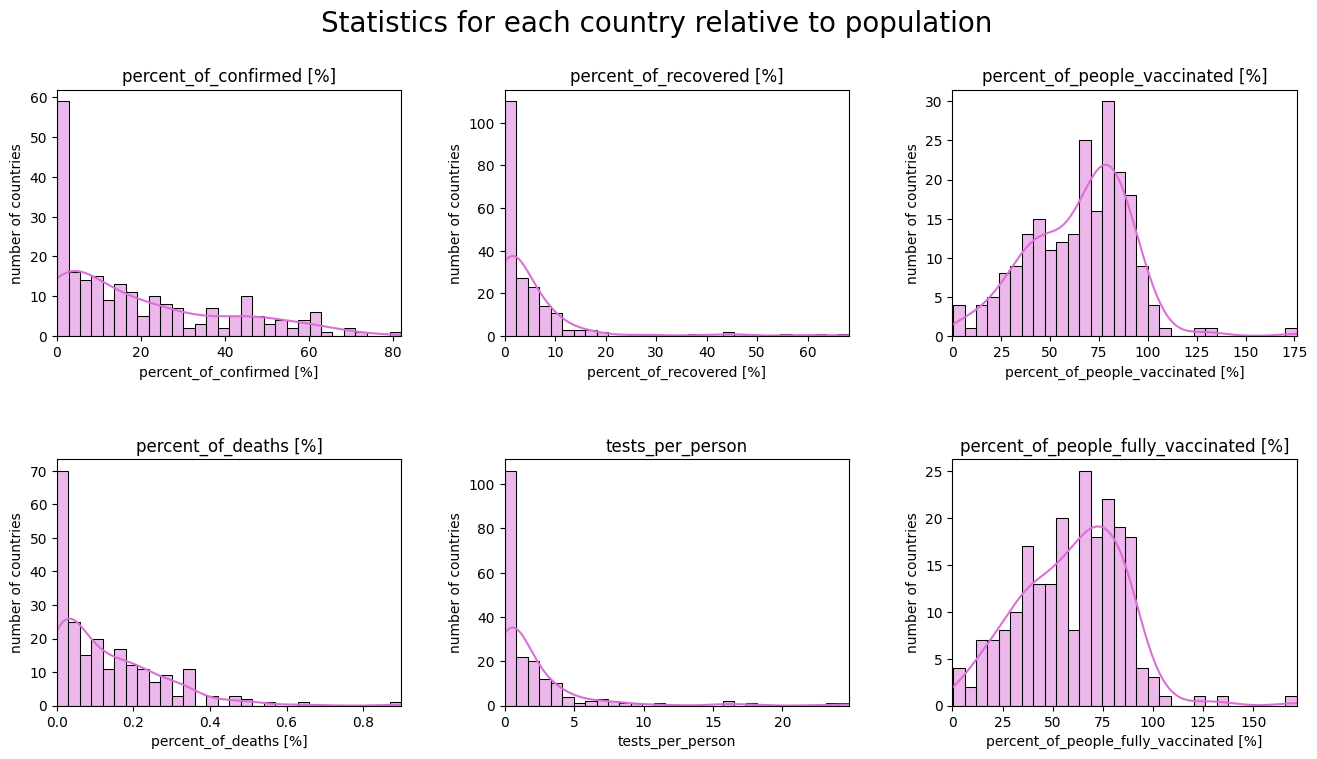

In [29]:
stats_features=['percent_of_confirmed [%]','percent_of_deaths [%]','percent_of_recovered [%]','tests_per_person','percent_of_people_vaccinated [%]','percent_of_people_fully_vaccinated [%]']
#feat_names=['odsetek potwierdzonych przypadków [%]','odsetek śmierci [%]','odsetek wyzdrowień [%]','liczba testów na osobę','odsetek zaszczepionych osób [%]','odsetek kompletnie zaszczepionych osób [%]']
fig,ax=plt.subplots(2,3,figsize=(16, 8))
plt.suptitle('Statistics for each country relative to population',fontsize=20)
plt.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(len(stats_features)):
    sns.histplot(df_stats[stats_features[i]].dropna(), bins=30, kde=True, ax=ax[i%2,i//2], color='orchid')
    ax[i%2,i//2].set_title(f'{stats_features[i]}')
    ax[i%2,i//2].set_xlabel(stats_features[i])
    ax[i%2,i//2].set_ylabel('number of countries')
    ax[i%2,i//2].set_xlim(0,max(df_stats[stats_features[i]].dropna()))


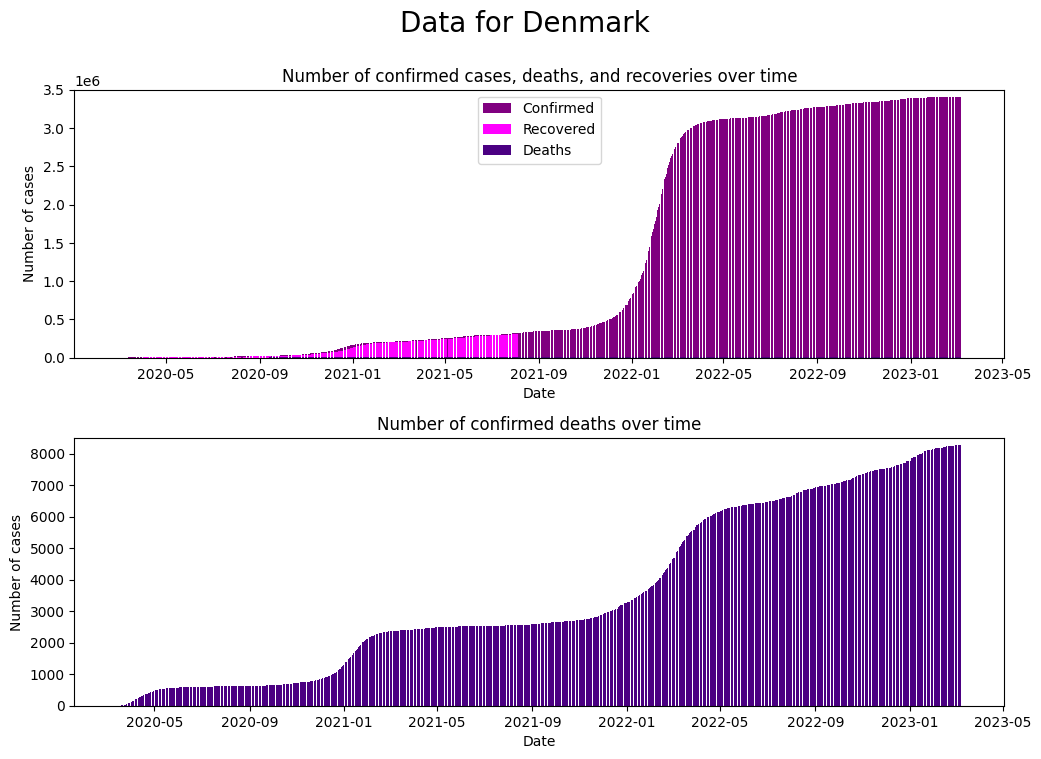

In [32]:
fig,ax=plt.subplots(2,1,figsize=(12,8))
plt.suptitle('Data for Denmark',fontsize=20)
plt.subplots_adjust(hspace=0.3)
ax[0].bar(df_denmark['date'], df_denmark['confirmed'], label='Confirmed', color='purple')
ax[0].bar(df_denmark['date'], df_denmark['recovered'], label='Recovered', color='magenta')
ax[0].bar(df_denmark['date'], df_denmark['deaths'], label='Deaths', color='indigo')
ax[0].set_title('Number of confirmed cases, deaths, and recoveries over time')
ax[0].set_xlabel('Date')
ax[0].set_ylim(0,3.5e6)
ax[0].set_ylabel('Number of cases')
ax[0].legend()

ax[1].bar(df_denmark['date'], df_denmark['deaths'], label='Deaths', color='indigo')
ax[1].set_title('Number of confirmed deaths over time')
ax[1].set_xlabel('Date')
ax[1].set_ylabel('Number of cases')
ax[1].set_ylim(0,8500)
plt.show()

In [33]:
df_denmark.columns

Index(['date', 'confirmed', 'deaths', 'recovered', 'tests', 'vaccines',
       'people_vaccinated', 'people_fully_vaccinated', 'hosp', 'icu', 'vent',
       'school_closing', 'workplace_closing', 'cancel_events',
       'gatherings_restrictions', 'transport_closing',
       'stay_home_restrictions', 'internal_movement_restrictions',
       'international_movement_restrictions', 'information_campaigns',
       'testing_policy', 'contact_tracing', 'facial_coverings',
       'vaccination_policy', 'elderly_people_protection',
       'government_response_index', 'stringency_index',
       'containment_health_index', 'economic_support_index',
       'administrative_area_level', 'administrative_area_level_1', 'latitude',
       'longitude', 'population', 'iso_alpha_3'],
      dtype='object')

In [34]:
df_denamrk=df_denmark[['date', 'confirmed', 'deaths', 'recovered', 'tests', 'vaccines',
       'people_vaccinated', 'people_fully_vaccinated', 'hosp', 'icu', 'vent',
       'school_closing', 'workplace_closing', 'cancel_events',
       'gatherings_restrictions', 'transport_closing',
       'stay_home_restrictions', 'internal_movement_restrictions',
       'international_movement_restrictions', 'information_campaigns',
       'testing_policy', 'contact_tracing', 'facial_coverings',
       'vaccination_policy', 'elderly_people_protection',
       'government_response_index', 'stringency_index',
       'containment_health_index', 'economic_support_index',]]

In [35]:
df_denmark

,date,confirmed,deaths,recovered,tests,vaccines,people_vaccinated,people_fully_vaccinated,hosp,icu,...,government_response_index,stringency_index,containment_health_index,economic_support_index,administrative_area_level,administrative_area_level_1,latitude,longitude,population,iso_alpha_3
115921,2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,1,Denmark,56.26,9.5,5793636.0,DNK
115922,2020-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,1,Denmark,56.26,9.5,5793636.0,DNK
115923,2020-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,1,Denmark,56.26,9.5,5793636.0,DNK
115924,2020-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,1,Denmark,56.26,9.5,5793636.0,DNK
115925,2020-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,1,Denmark,56.26,9.5,5793636.0,DNK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117101,2023-03-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,347.0,11.0,...,NaN,NaN,NaN,NaN,1,Denmark,56.26,9.5,5793636.0,DNK
117102,2023-03-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0,...,NaN,NaN,NaN,NaN,1,Denmark,56.26,9.5,5793636.0,DNK
117103,2023-03-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,...,NaN,NaN,NaN,NaN,1,Denmark,56.26,9.5,5793636.0,DNK
117104,2023-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,...,NaN,NaN,NaN,NaN,1,Denmark,56.26,9.5,5793636.0,DNK


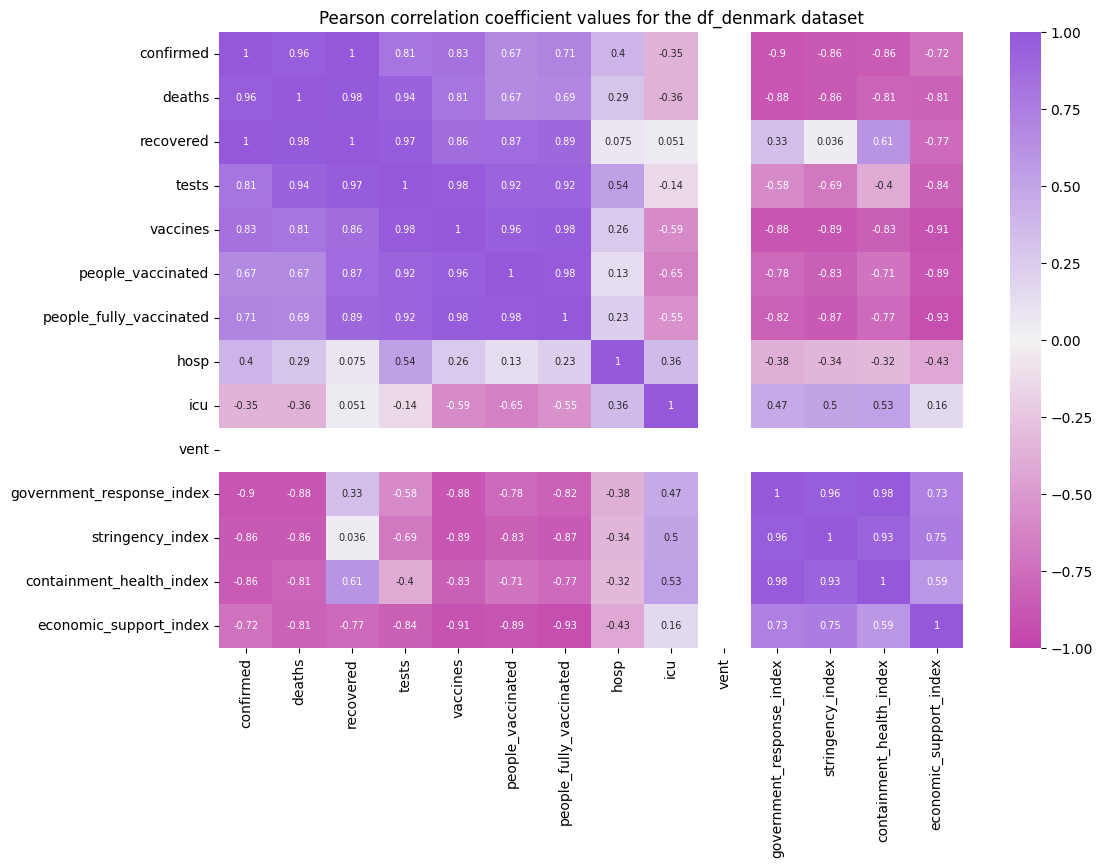

In [36]:
df_denmark_corr=df_denmark[['confirmed', 'deaths', 'recovered', 'tests', 'vaccines',
       'people_vaccinated', 'people_fully_vaccinated', 'hosp', 'icu', 'vent',
       'government_response_index', 'stringency_index',
       'containment_health_index', 'economic_support_index']]
#df_denmark = df_denmark.astype(float)
correlation_matrix=df_denmark_corr.corr(method='pearson')

plt.figure(figsize=(12, 8))
cmap=sns.diverging_palette(320, 280, as_cmap=True)
sns.heatmap(correlation_matrix, annot=True, annot_kws={"size": 7}, cmap=cmap,vmax=1, vmin= -1)
plt.title('Pearson correlation coefficient values for the df_denmark dataset')
plt.show()

In [37]:
! pip install missingno

In [38]:
import missingno as msno

<Axes: >

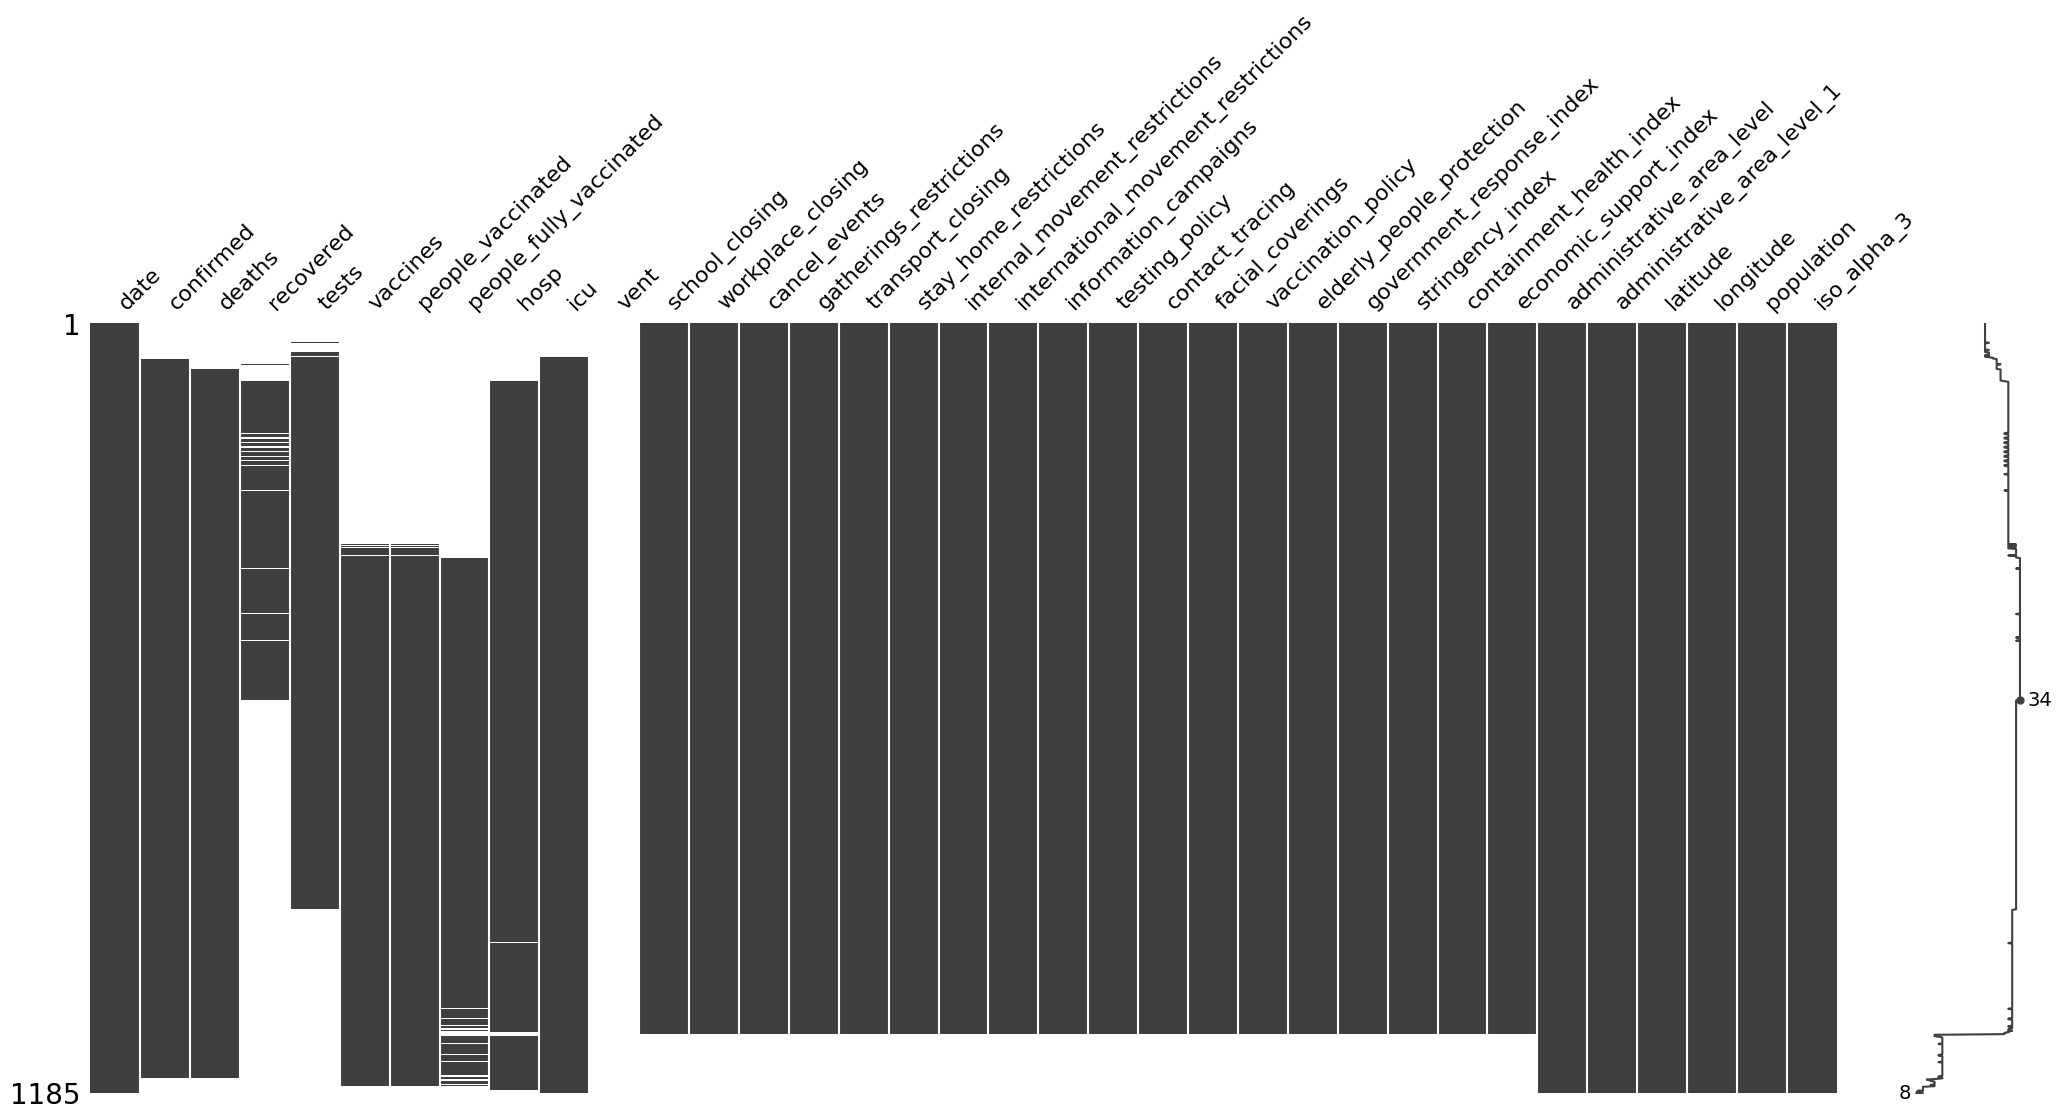

In [39]:
msno.matrix(df_denmark)

In [40]:
df_denmark=df[df['iso_alpha_3']=='DNK']
df_denmark=df_denmark[['date', 'confirmed', 'deaths', 'recovered', 'tests', 'vaccines',
       'people_vaccinated', 'people_fully_vaccinated', 'hosp', 'icu', 'vent',
       'containment_health_index', 'economic_support_index']]
df_denmark=df_denmark.reset_index()
df_denmark

,index,date,confirmed,deaths,recovered,tests,vaccines,people_vaccinated,people_fully_vaccinated,hosp,icu,vent,containment_health_index,economic_support_index
0,115921,2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1,115922,2020-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2,115923,2020-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
3,115924,2020-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
4,115925,2020-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1180,117101,2023-03-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,347.0,11.0,NaN,NaN,NaN
1181,117102,2023-03-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0,NaN,NaN,NaN
1182,117103,2023-03-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,NaN,NaN,NaN
1183,117104,2023-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,NaN


In [42]:
df_denmark.isnull().sum()
for column in df_denmark.columns:
    missing_indices = df_denmark[df_denmark[column].isnull()].index
    if len(missing_indices) > 0:
        print(f"Column '{column}' has missing values in rows: {list(missing_indices)}")
    else:
        print(f"Column '{column}' has no missing values")

Column 'index' has no missing values
Column 'date' has no missing values
Column 'confirmed' has missing values in rows: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 1162, 1163, 1164, 1165, 1166, 1167, 1168, 1169, 1170, 1171, 1172, 1173, 1174, 1175, 1176, 1177, 1178, 1179, 1180, 1181, 1182, 1183, 1184]
Column 'deaths' has missing values in rows: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 1162, 1163, 1164, 1165, 1166, 1167, 1168, 1169, 1170, 1171, 1172, 1173, 1174, 1175, 1176, 1177, 1178, 1179, 1180, 1181, 1182, 1183, 1184]
Column 'recovered' has missing values in rows: [0, 1, 2, 3, 4, 5, 6, 7, 8,

In [43]:
drop_range=[range(0,55),range(1162,1185)]
indices_to_remove=[i for r in drop_range for i in r]
df_denmark=df_denmark.drop(indices_to_remove)
df_denmark=df_denmark.reset_index(drop=True)
df_denmark=df_denmark.drop('index', axis=1)
df_denmark

,date,confirmed,deaths,recovered,tests,vaccines,people_vaccinated,people_fully_vaccinated,hosp,icu,vent,containment_health_index,economic_support_index
0,2020-02-27,1.0,NaN,NaN,158.0,NaN,NaN,NaN,NaN,0.0,NaN,13.1,0.0
1,2020-02-28,1.0,NaN,NaN,220.0,NaN,NaN,NaN,NaN,0.0,NaN,13.1,0.0
2,2020-02-29,3.0,NaN,NaN,294.0,NaN,NaN,NaN,NaN,0.0,NaN,13.1,0.0
3,2020-03-01,4.0,NaN,NaN,343.0,NaN,NaN,NaN,NaN,0.0,NaN,13.1,0.0
4,2020-03-02,4.0,NaN,NaN,423.0,NaN,NaN,NaN,NaN,0.0,NaN,13.1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102,2023-03-05,3403707.0,8274.0,NaN,NaN,13129629.0,4781534.0,4746288.0,179.0,7.0,NaN,NaN,NaN
1103,2023-03-06,3403958.0,8284.0,NaN,NaN,13129661.0,4781543.0,NaN,189.0,9.0,NaN,NaN,NaN
1104,2023-03-07,3404128.0,8285.0,NaN,NaN,13129680.0,4781545.0,NaN,183.0,6.0,NaN,NaN,NaN
1105,2023-03-08,3404268.0,8292.0,NaN,NaN,13129705.0,4781549.0,4746291.0,203.0,6.0,NaN,NaN,NaN


<Axes: >

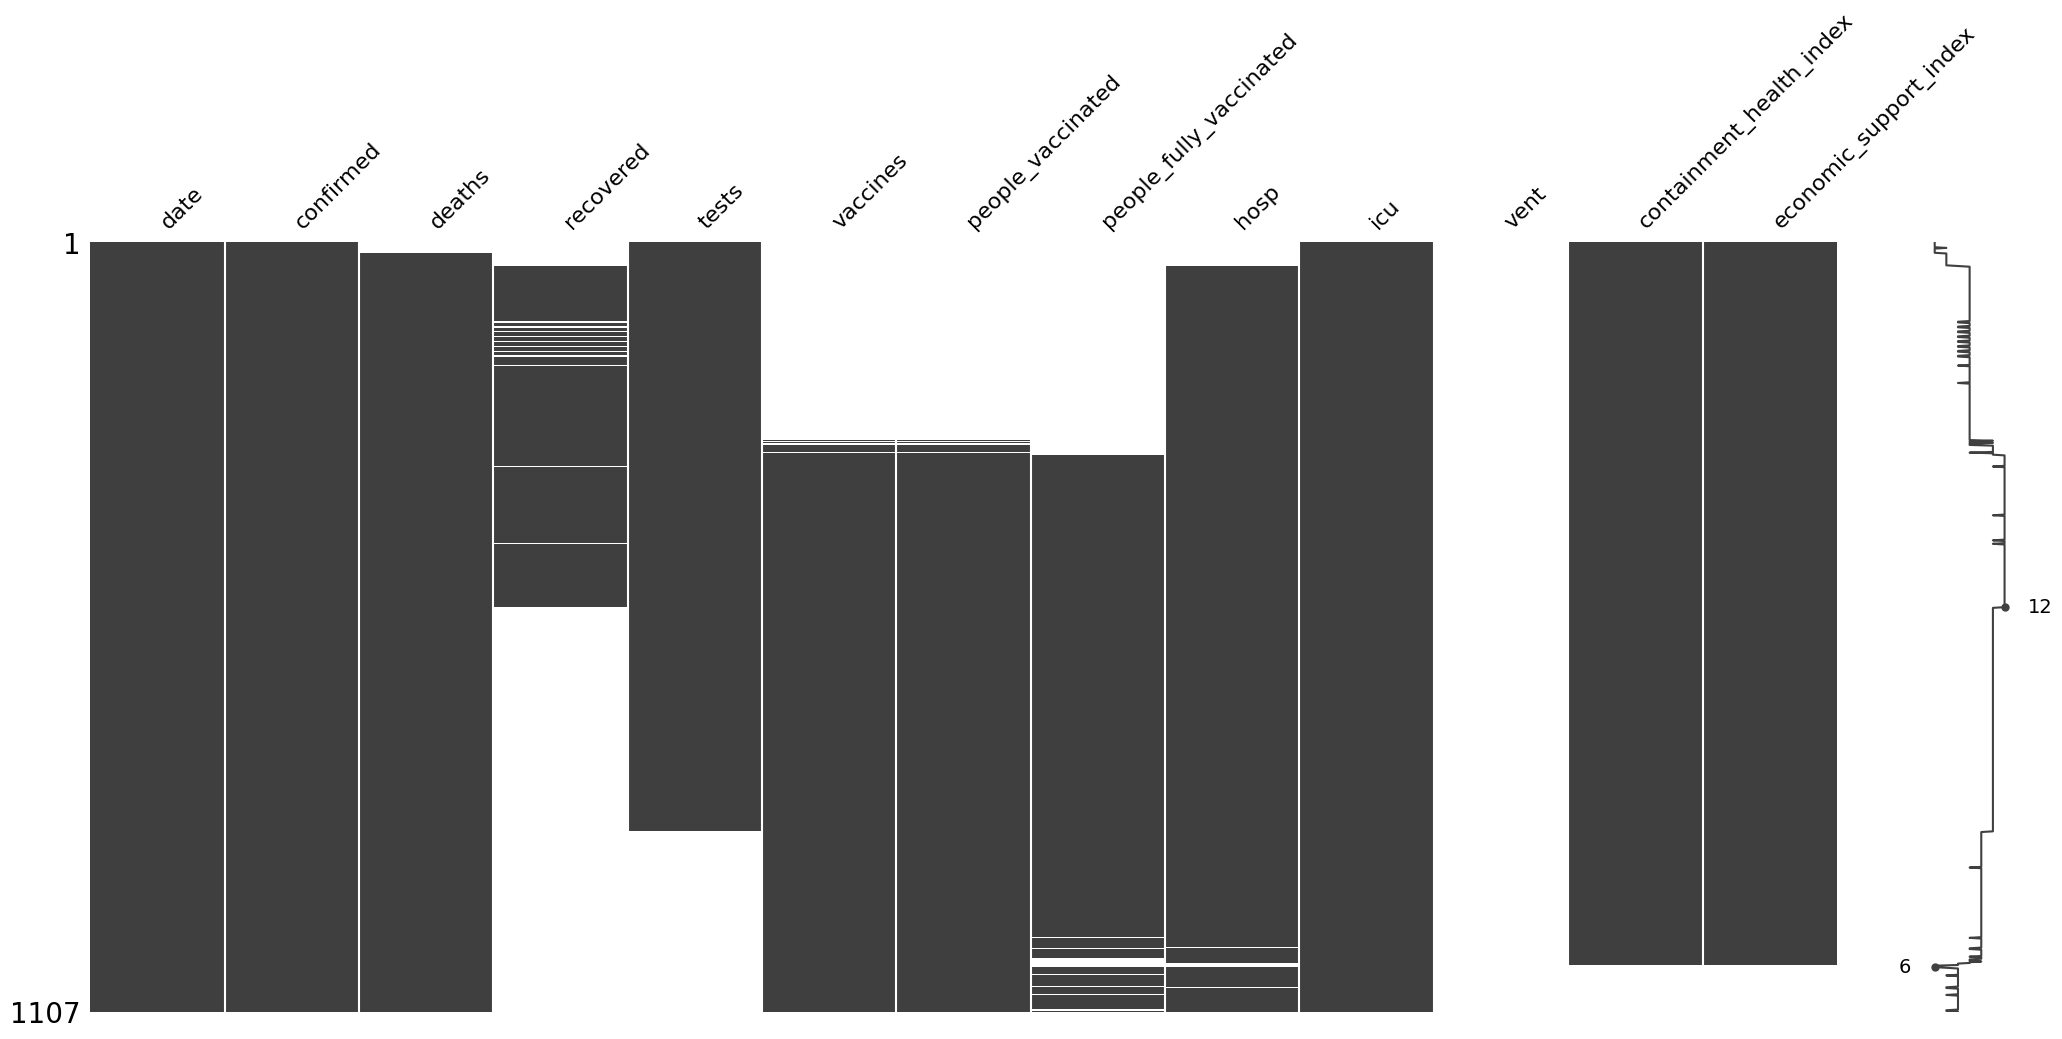

In [44]:
msno.matrix(df_denmark)

In [45]:
df_denmark.isnull().sum()
for column in df_denmark.columns:
    missing_indices = df_denmark[df_denmark[column].isnull()].index
    if len(missing_indices) > 0:
        print(f"Column '{column}' has missing values in rows: {list(missing_indices)}")
    else:
        print(f"Column '{column}' has no missing values")

Column 'date' has no missing values
Column 'confirmed' has no missing values
Column 'deaths' has missing values in rows: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Column 'recovered' has missing values in rows: [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 114, 115, 121, 122, 128, 129, 135, 136, 142, 143, 149, 150, 156, 157, 163, 164, 177, 202, 322, 392, 428, 433, 525, 526, 527, 528, 529, 530, 531, 532, 533, 534, 535, 536, 537, 538, 539, 540, 541, 542, 543, 544, 545, 546, 547, 548, 549, 550, 551, 552, 553, 554, 555, 556, 557, 558, 559, 560, 561, 562, 563, 564, 565, 566, 567, 568, 569, 570, 571, 572, 573, 574, 575, 576, 577, 578, 579, 580, 581, 582, 583, 584, 585, 586, 587, 588, 589, 590, 591, 592, 593, 594, 595, 596, 597, 598, 599, 600, 601, 602, 603, 604, 605, 606, 607, 608, 609, 610, 611, 612, 613, 614, 615, 616, 617, 618, 619, 620, 621, 622, 623, 624, 625, 626, 627, 628, 629, 630, 631, 632, 633

In [46]:
df_denmark=df_denmark.drop('recovered',axis=1)
df_denmark=df_denmark.drop('vent',axis=1)

In [47]:
df_denmark.loc[:15,'deaths'] = df_denmark.loc[:15,'deaths'].fillna(0)
df_denmark.loc[:291,'vaccines'] = df_denmark.loc[:291,'vaccines'].fillna(0)
df_denmark.loc[:291,'people_vaccinated'] = df_denmark.loc[:291,'people_vaccinated'].fillna(0)
df_denmark.loc[:305,'people_fully_vaccinated'] = df_denmark.loc[:305,'people_fully_vaccinated'].fillna(0)
df_denmark.loc[:34,'hosp'] = df_denmark.loc[:34,'hosp'].fillna(0)

<Axes: >

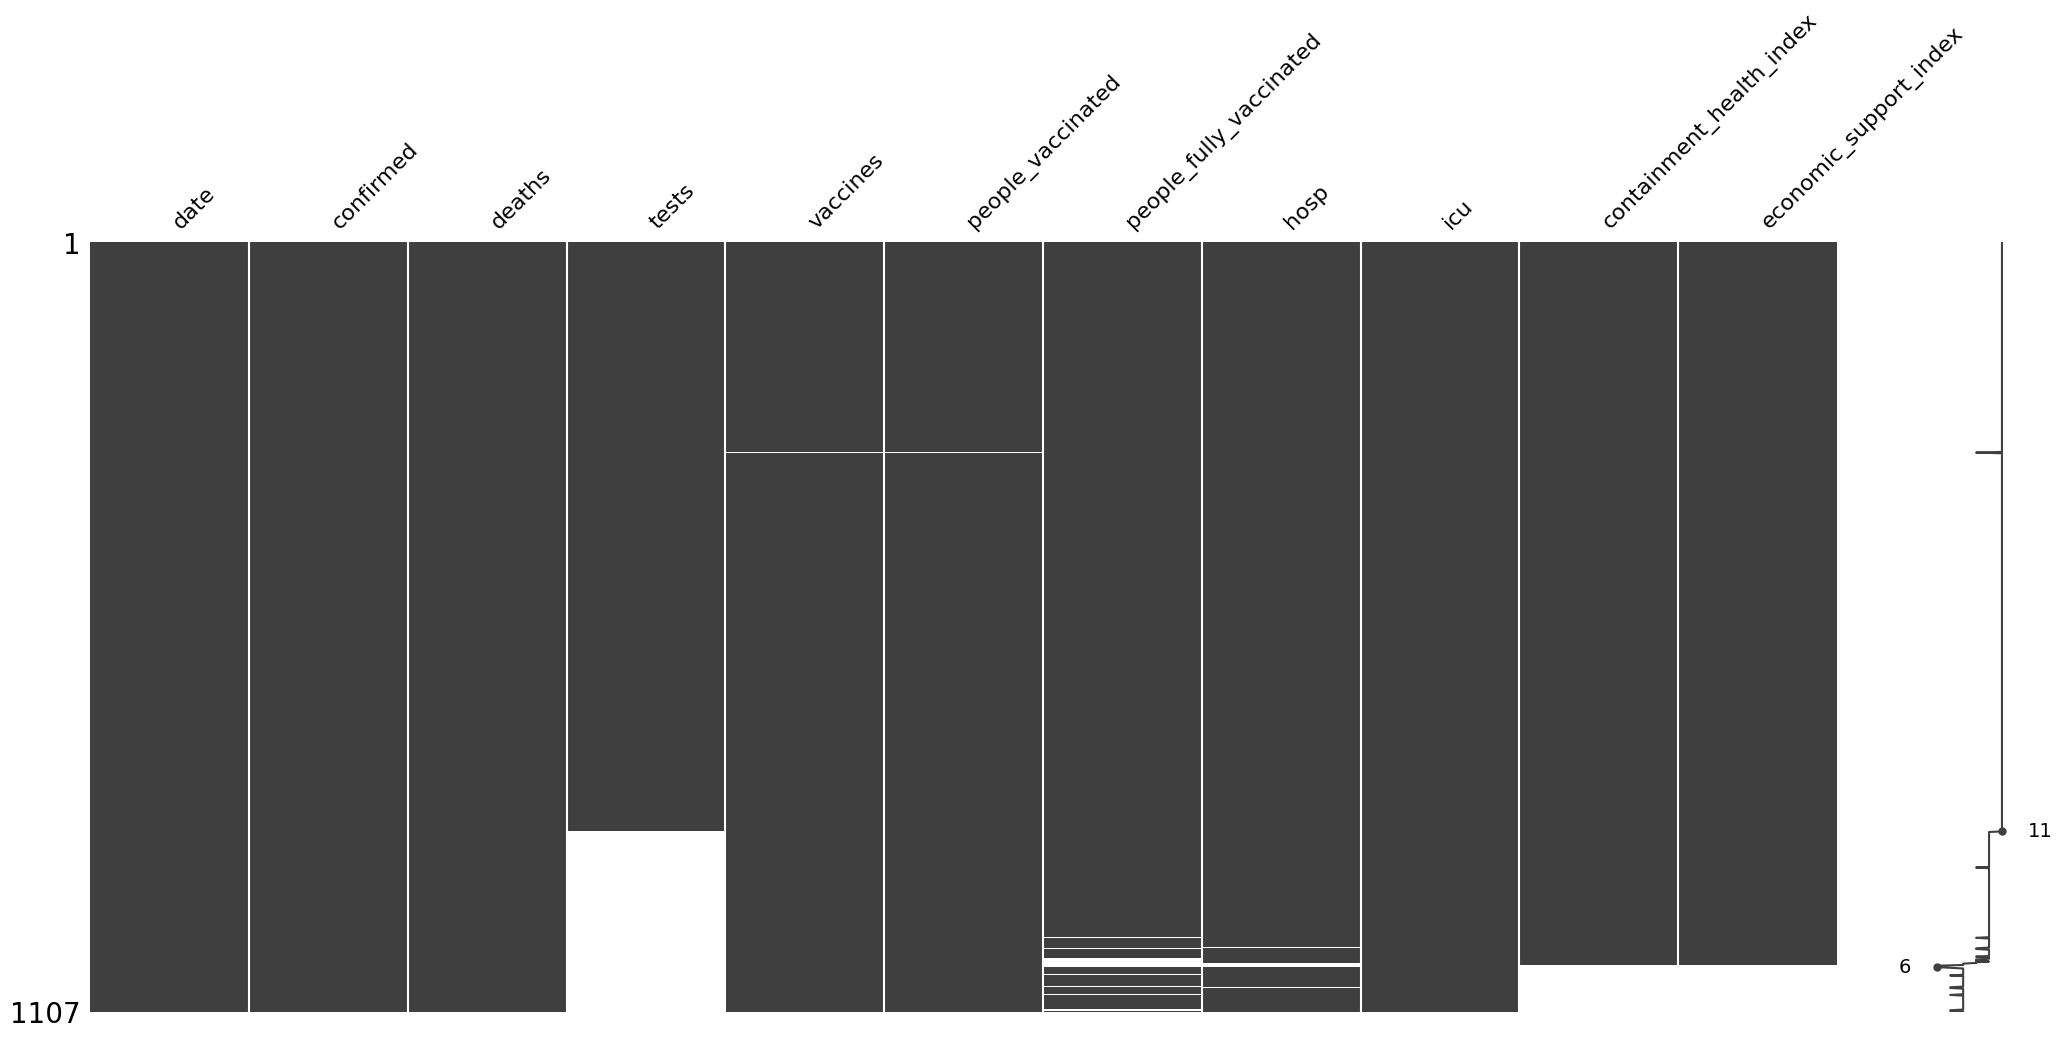

In [48]:
msno.matrix(df_denmark)

In [49]:
ffill_col=['tests','vaccines', 'people_vaccinated', 'people_fully_vaccinated', 'hosp',
       'containment_health_index', 'economic_support_index']
for col in ffill_col:
  df_denmark[col] = df_denmark[col].interpolate(method='linear')

df_denmark['tests']=df_denmark['tests'].ffill()
df_denmark

,date,confirmed,deaths,tests,vaccines,people_vaccinated,people_fully_vaccinated,hosp,icu,containment_health_index,economic_support_index
0,2020-02-27,1.0,0.0,158.0,0.0,0.0,0.0,0.0,0.0,13.10,0.0
1,2020-02-28,1.0,0.0,220.0,0.0,0.0,0.0,0.0,0.0,13.10,0.0
2,2020-02-29,3.0,0.0,294.0,0.0,0.0,0.0,0.0,0.0,13.10,0.0
3,2020-03-01,4.0,0.0,343.0,0.0,0.0,0.0,0.0,0.0,13.10,0.0
4,2020-03-02,4.0,0.0,423.0,0.0,0.0,0.0,0.0,0.0,13.10,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1102,2023-03-05,3403707.0,8274.0,64649913.0,13129629.0,4781534.0,4746288.0,179.0,7.0,23.81,0.0
1103,2023-03-06,3403958.0,8284.0,64649913.0,13129661.0,4781543.0,4746289.0,189.0,9.0,23.81,0.0
1104,2023-03-07,3404128.0,8285.0,64649913.0,13129680.0,4781545.0,4746290.0,183.0,6.0,23.81,0.0
1105,2023-03-08,3404268.0,8292.0,64649913.0,13129705.0,4781549.0,4746291.0,203.0,6.0,23.81,0.0


<Axes: >

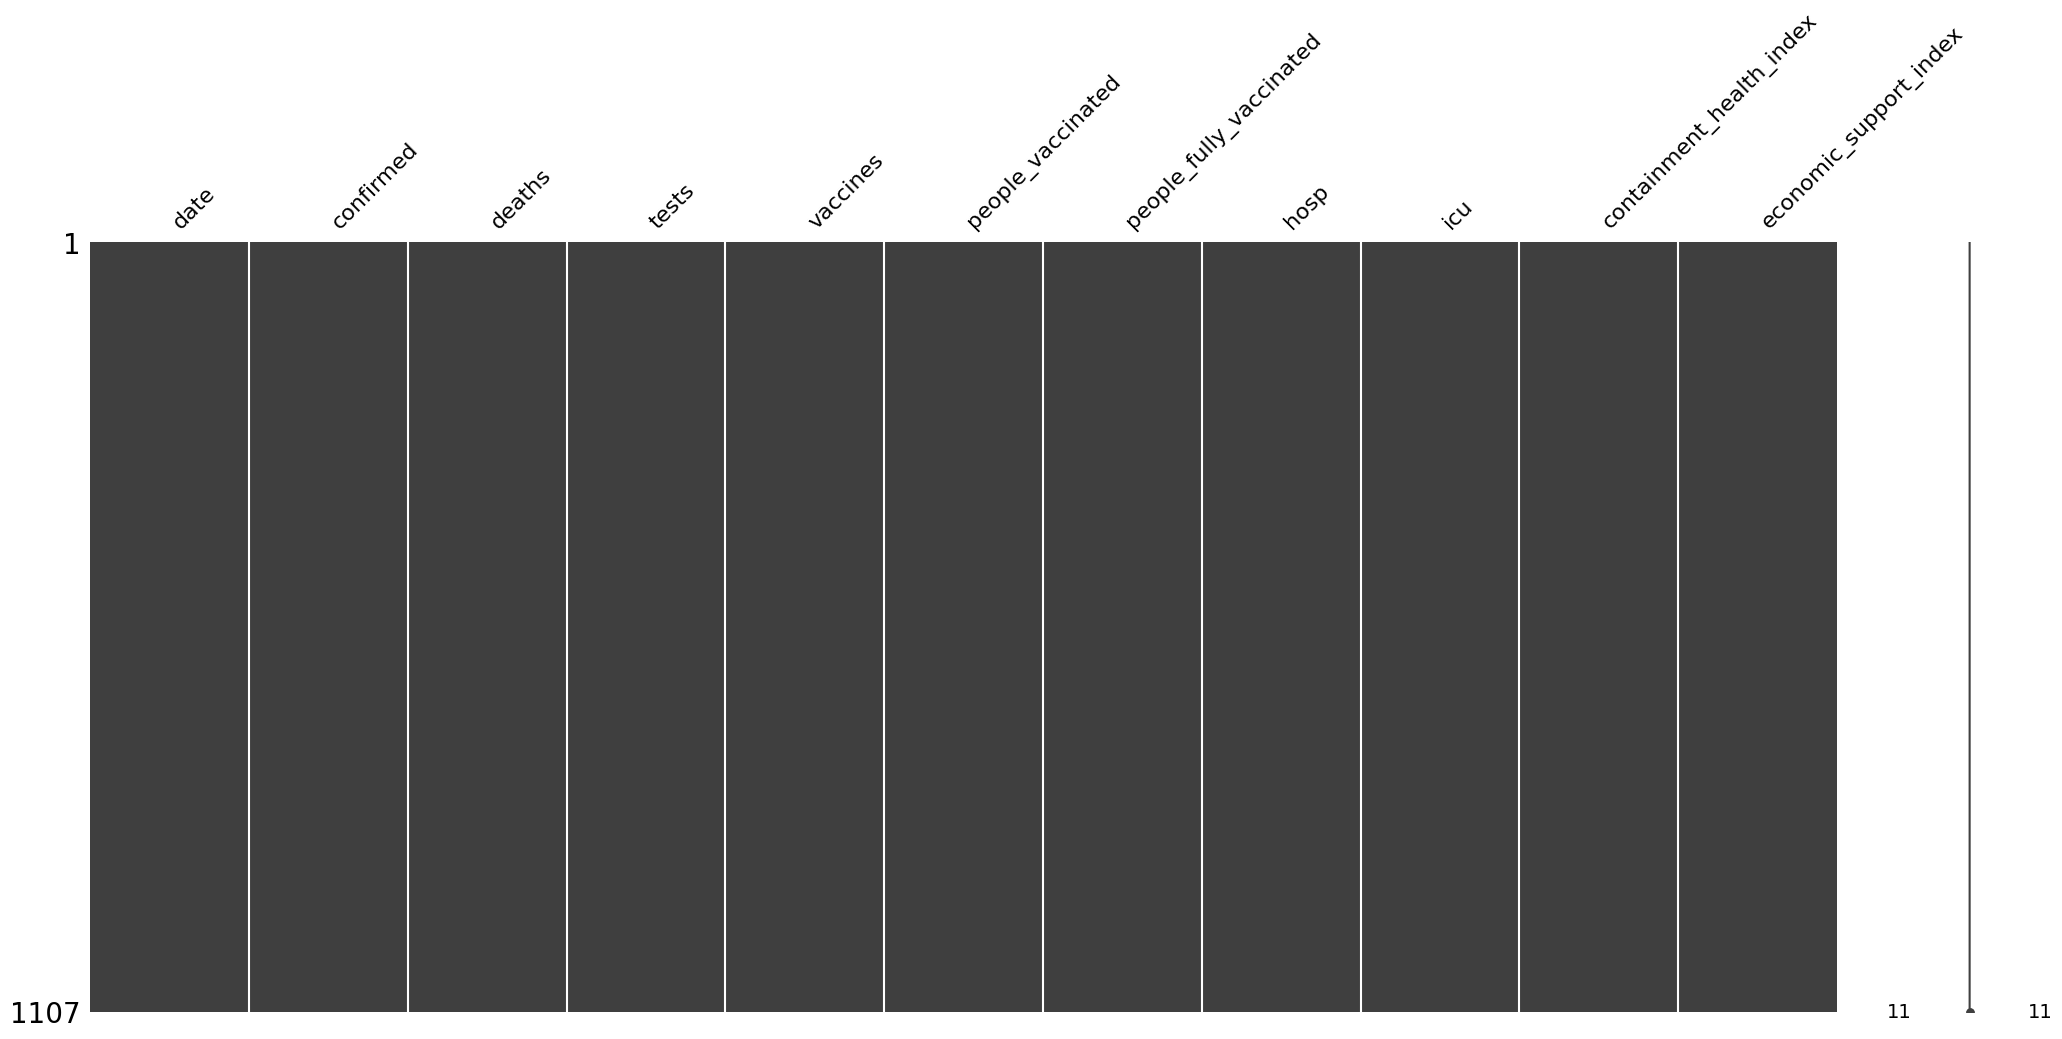

In [50]:
msno.matrix(df_denmark)

In [51]:
df_denmark.isnull().sum()

,0
date,0
confirmed,0
deaths,0
tests,0
vaccines,0
people_vaccinated,0
people_fully_vaccinated,0
hosp,0
icu,0
containment_health_index,0


In [52]:
df_denmark.tail(20)

,date,confirmed,deaths,tests,vaccines,people_vaccinated,people_fully_vaccinated,hosp,icu,containment_health_index,economic_support_index
1087,2023-02-18,3402118.0,8228.0,64649913.0,13129194.0,4781458.0,4746196.0,179.0,8.0,23.81,0.0
1088,2023-02-19,3402118.0,8228.0,64649913.0,13129224.0,4781462.0,4746211.0,197.0,7.0,23.81,0.0
1089,2023-02-20,3402426.0,8237.0,64649913.0,13129266.0,4781473.0,4746218.0,209.0,7.0,23.81,0.0
1090,2023-02-21,3402590.0,8237.0,64649913.0,13129316.0,4781478.0,4746233.0,205.0,9.0,23.81,0.0
1091,2023-02-22,3402710.0,8239.0,64649913.0,13129360.0,4781486.0,4746239.0,198.0,7.0,23.81,0.0
1092,2023-02-23,3402848.0,8240.0,64649913.0,13129404.0,4781495.0,4746249.0,199.0,8.0,23.81,0.0
1093,2023-02-24,3402975.0,8244.0,64649913.0,13129425.0,4781499.0,4746253.0,199.0,8.0,23.81,0.0
1094,2023-02-25,3402975.0,8244.0,64649913.0,13129435.0,4781499.0,4746257.0,192.0,7.0,23.81,0.0
1095,2023-02-26,3402975.0,8244.0,64649913.0,13129459.0,4781504.0,4746266.0,182.0,5.0,23.81,0.0
1096,2023-02-27,3403225.0,8255.0,64649913.0,13129495.0,4781506.0,4746274.0,195.0,7.0,23.81,0.0


In [53]:
df_denmark['days_since_first_case']=(df_denmark['date']-df_denmark['date'].min()).dt.days

In [54]:
x=df_denmark['deaths']
np.matrix(x).T

matrix([[   0.],
        [   0.],
        [   0.],
        ...,
        [8285.],
        [8292.],
        [8296.]])

In [55]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [56]:
features=['tests', 'vaccines',
       'people_vaccinated', 'people_fully_vaccinated', 'hosp', 'icu',
       'containment_health_index', 'economic_support_index','days_since_first_case']

results_conf = pd.DataFrame(columns=['Feature', 'MSE', 'RMSE', 'MAE', 'R2'])
results_death = pd.DataFrame(columns=['Feature', 'MSE', 'RMSE', 'MAE', 'R2'])

for feat in features:
  feat_1dim=df_denmark[feat]
  X=np.matrix(feat_1dim).T.A
  y_conf=df_denmark['confirmed']
  y_death=df_denmark['deaths']
  X_train_conf, X_test_conf, y_train_conf, y_test_conf=train_test_split(X,y_conf,test_size=0.2,random_state=42)
  X_train_death, X_test_death, y_train_death, y_test_death=train_test_split(X,y_death,test_size=0.2,random_state=42)

  scaler=MinMaxScaler()
  X_train_conf=scaler.fit_transform(X_train_conf)
  X_test_conf=scaler.transform(X_test_conf)

  X_train_death=scaler.fit_transform(X_train_death)
  X_test_death=scaler.transform(X_test_death)

  lr_conf=LinearRegression()
  lr_conf.fit(X_train_conf, y_train_conf)
  y_conf_pred=lr_conf.predict(X_test_conf)
  mse_conf=mean_squared_error(y_test_conf, y_conf_pred)
  rmse_conf=np.sqrt(mse_conf)
  mae_conf=mean_absolute_error(y_test_conf,y_conf_pred)
  r2_conf=r2_score(y_test_conf, y_conf_pred)

  lr_death=LinearRegression()
  lr_death.fit(X_train_death, y_train_death)
  y_death_pred=lr_death.predict(X_test_death)
  mse_death=mean_squared_error(y_test_death, y_death_pred)
  rmse_death=np.sqrt(mse_death)
  mae_death=mean_absolute_error(y_test_death,y_death_pred)
  r2_death=r2_score(y_test_death, y_death_pred)

  results_conf=pd.concat([results_conf, pd.DataFrame({'Feature': [feat], 'MSE': [mse_conf], 'RMSE': [rmse_conf], 'MAE': [mae_conf], 'R2': [r2_conf]})], ignore_index=True)
  results_death=pd.concat([results_death, pd.DataFrame({'Feature': [feat], 'MSE': [mse_death], 'RMSE': [rmse_death], 'MAE': [mae_death], 'R2': [r2_death]})], ignore_index=True)

results_conf

/tmp/ipython-input-914/2659120945.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_conf=pd.concat([results_conf, pd.DataFrame({'Feature': [feat], 'MSE': [mse_conf], 'RMSE': [rmse_conf], 'MAE': [mae_conf], 'R2': [r2_conf]})], ignore_index=True)
/tmp/ipython-input-914/2659120945.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_death=pd.concat([results_death, pd.DataFrame({'Feature': [feat], 'MSE': [mse_death], 'RMSE': [rmse_death], 'MAE': [mae_death], 'R2': [r2_death]})], i

,Feature,MSE,RMSE,MAE,R2
0,tests,4.357557e+11,6.601180e+05,5.719169e+05,0.787032
1,vaccines,4.339991e+11,6.587860e+05,5.220769e+05,0.787890
2,people_vaccinated,8.061596e+11,8.978639e+05,6.928129e+05,0.606003
3,people_fully_vaccinated,6.699501e+11,8.185048e+05,6.092763e+05,0.672573
4,hosp,1.635947e+12,1.279042e+06,1.141026e+06,0.200459
5,icu,1.781154e+12,1.334599e+06,1.246681e+06,0.129491
6,containment_health_index,4.736733e+11,6.882393e+05,5.238599e+05,0.768500
7,economic_support_index,8.456420e+11,9.195879e+05,8.011316e+05,0.586707
8,days_since_first_case,3.985092e+11,6.312758e+05,5.489016e+05,0.805235


/tmp/ipython-input-914/600397226.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0,0].set_xticklabels(ax[0,0].get_xticklabels(), rotation=90)
/tmp/ipython-input-914/600397226.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0,1].set_xticklabels(ax[0,1].get_xticklabels(), rotation=90)
/tmp/ipython-input-914/600397226.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0,2].set_xticklabels(ax[0,2].get_xticklabels(), rotation=90)
/tmp/ipython-input-914/600397226.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0,3].set_xticklabels(ax[0,3].get_xticklabels(), rotation=90)
/tmp/ipython-input-914/600397226.py:33: UserWarning: set_ticklabe

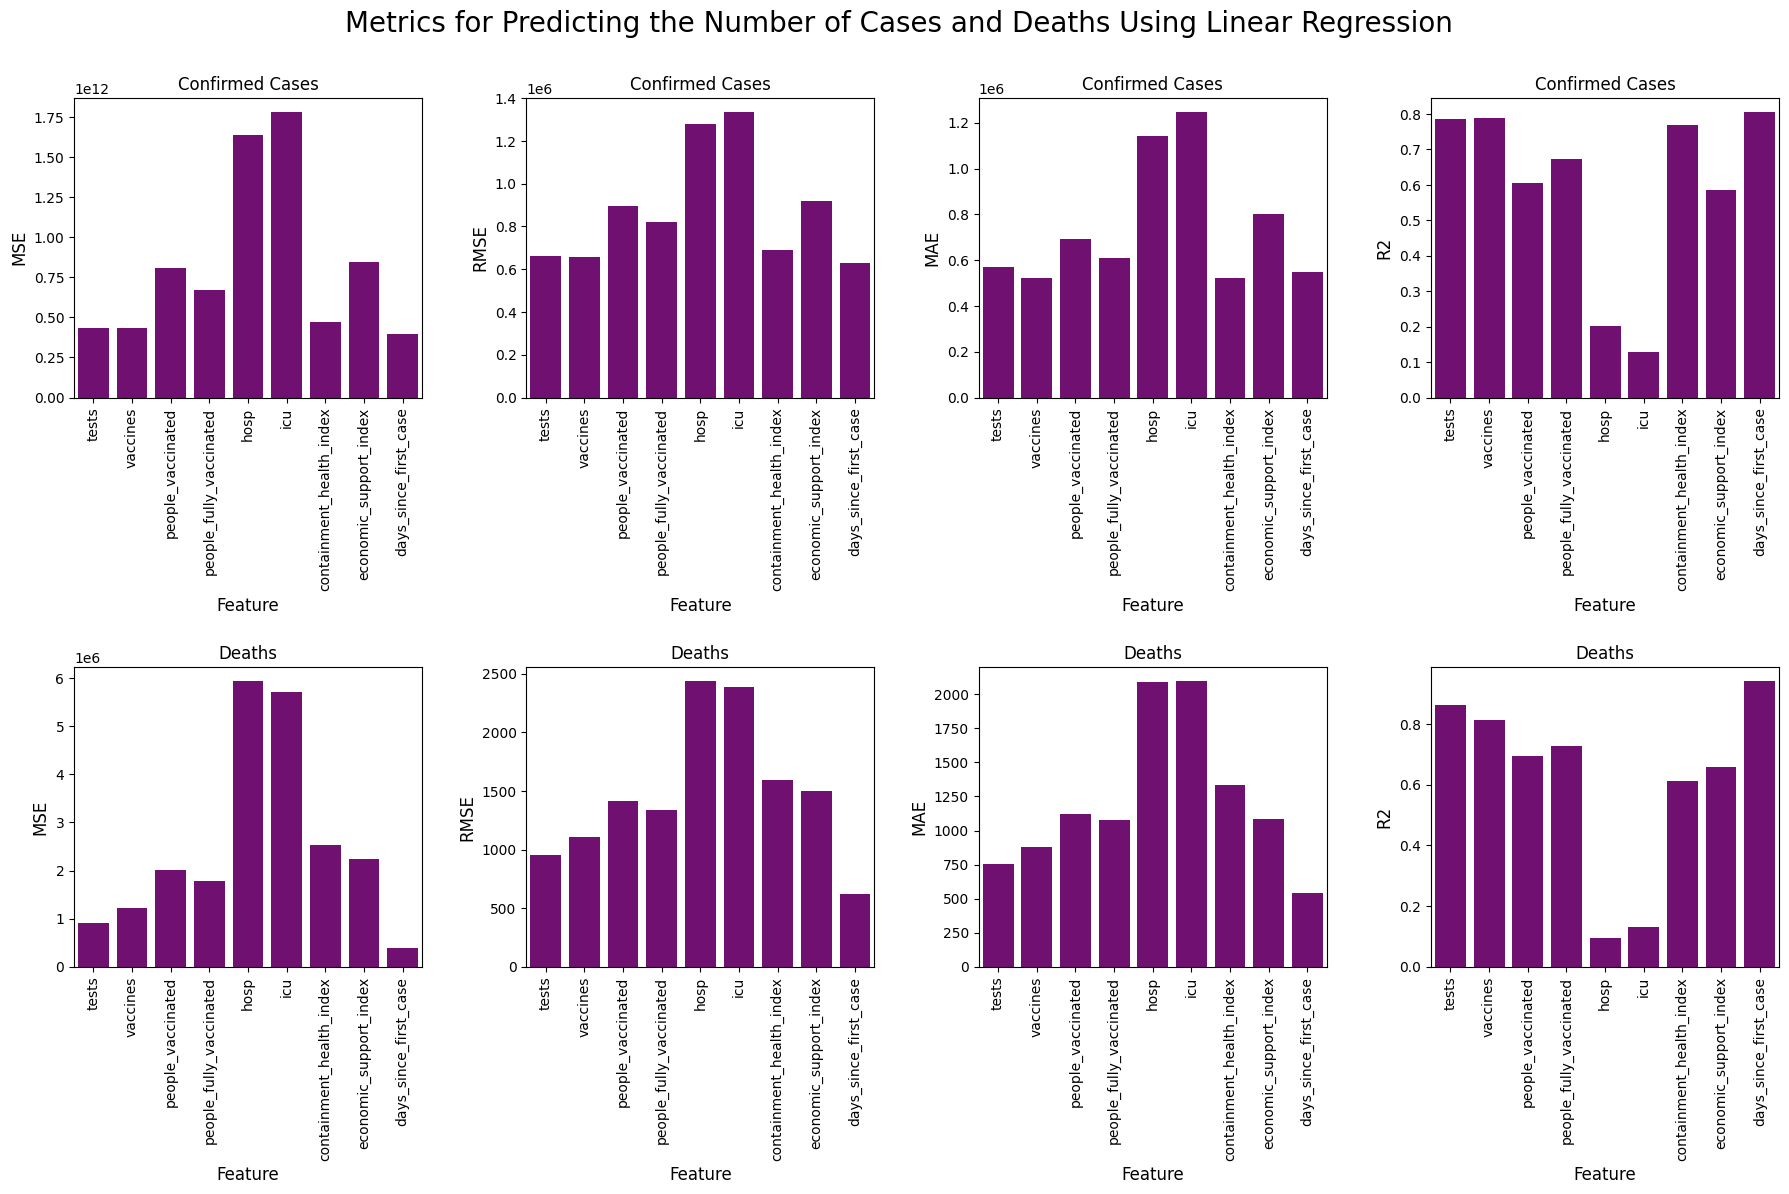

In [57]:
fig, ax = plt.subplots(2, 4, figsize=(22, 11))
plt.suptitle('Metrics for Predicting the Number of Cases and Deaths Using Linear Regression', fontsize=20)
plt.subplots_adjust(top=0.9, hspace=0.9, wspace=0.3)

sns.barplot(x=results_conf['Feature'], y=results_conf['MSE'], ax=ax[0, 0], color='purple')
ax[0,0].set_title('Confirmed Cases')
ax[0,0].set_ylabel('MSE', fontsize=12)
ax[0,0].set_xlabel('Feature', fontsize=12)
ax[0,0].set_xticklabels(ax[0,0].get_xticklabels(), rotation=90)

sns.barplot(x=results_conf['Feature'], y=results_conf['RMSE'], ax=ax[0, 1], color='purple')
ax[0,1].set_title('Confirmed Cases')
ax[0,1].set_ylabel('RMSE', fontsize=12)
ax[0,1].set_xlabel('Feature', fontsize=12)
ax[0,1].set_xticklabels(ax[0,1].get_xticklabels(), rotation=90)

sns.barplot(x=results_conf['Feature'], y=results_conf['MAE'], ax=ax[0, 2], color='purple')
ax[0,2].set_title('Confirmed Cases')
ax[0,2].set_ylabel('MAE', fontsize=12)
ax[0,2].set_xlabel('Feature', fontsize=12)
ax[0,2].set_xticklabels(ax[0,2].get_xticklabels(), rotation=90)

sns.barplot(x=results_conf['Feature'], y=results_conf['R2'], ax=ax[0, 3], color='purple')
ax[0,3].set_title('Confirmed Cases')
ax[0,3].set_ylabel('R2', fontsize=12)
ax[0,3].set_xlabel('Feature', fontsize=12)
ax[0,3].set_xticklabels(ax[0,3].get_xticklabels(), rotation=90)

sns.barplot(x=results_death['Feature'], y=results_death['MSE'], ax=ax[1, 0], color='purple')
ax[1,0].set_title('Deaths')
ax[1,0].set_ylabel('MSE', fontsize=12)
ax[1,0].set_xlabel('Feature', fontsize=12)
ax[1,0].set_xticklabels(ax[1,0].get_xticklabels(), rotation=90)

sns.barplot(x=results_death['Feature'], y=results_death['RMSE'], ax=ax[1, 1], color='purple')
ax[1,1].set_title('Deaths')
ax[1,1].set_ylabel('RMSE', fontsize=12)
ax[1,1].set_xlabel('Feature', fontsize=12)
ax[1,1].set_xticklabels(ax[1,1].get_xticklabels(), rotation=90)

sns.barplot(x=results_death['Feature'], y=results_death['MAE'], ax=ax[1, 2], color='purple')
ax[1,2].set_title('Deaths')
ax[1,2].set_ylabel('MAE', fontsize=12)
ax[1,2].set_xlabel('Feature', fontsize=12)
ax[1,2].set_xticklabels(ax[1,2].get_xticklabels(), rotation=90)

sns.barplot(x=results_death['Feature'], y=results_death['R2'], ax=ax[1, 3], color='purple')
ax[1,3].set_title('Deaths')
ax[1,3].set_ylabel('R2', fontsize=12)
ax[1,3].set_xlabel('Feature', fontsize=12)
ax[1,3].set_xticklabels(ax[1,3].get_xticklabels(), rotation=90)

plt.show()

In [58]:
from scipy.stats import norm

Text(0, 0.5, 'Observed quantiles')

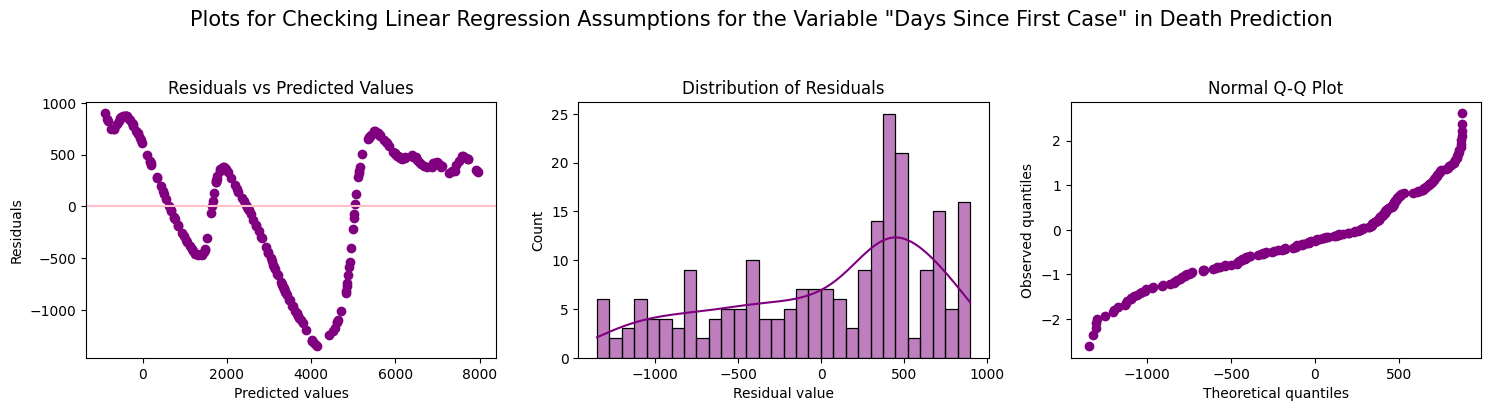

In [59]:
feat_1dim = df_denmark['days_since_first_case']
X = np.matrix(feat_1dim).T.A
y_death = df_denmark['deaths']

X_train_death_days, X_test_death_days, y_train_death_days, y_test_death_days = train_test_split(
    X, y_death, test_size=0.2, random_state=42
)

scaler = MinMaxScaler()
X_train_death_days_sc = scaler.fit_transform(X_train_death_days)
X_test_death_days_sc = scaler.transform(X_test_death_days)

lr_death_days = LinearRegression()
lr_death_days.fit(X_train_death_days_sc, y_train_death_days)
y_pred_death_days = lr_death_days.predict(X_test_death_days_sc)

residual_death_days = y_test_death_days - y_pred_death_days
x = np.sort(residual_death_days)
y = norm.ppf(np.linspace(0, 1, len(x)))

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
plt.suptitle(
    'Plots for Checking Linear Regression Assumptions for the Variable "Days Since First Case" in Death Prediction',
    fontsize=15
)
plt.subplots_adjust(top=0.75)

ax[0].scatter(y_pred_death_days, residual_death_days, color='purple')
ax[0].set_title('Residuals vs Predicted Values')
ax[0].set_xlabel('Predicted values')
ax[0].set_ylabel('Residuals')
ax[0].axhline(y=0, color='pink')

sns.histplot(residual_death_days, kde=True, bins=30, ax=ax[1], color='purple')
ax[1].set_title('Distribution of Residuals')
ax[1].set_xlabel('Residual value')
ax[1].set_ylabel('Count')

ax[2].scatter(x, y, color='purple')
ax[2].set_title('Normal Q-Q Plot')
ax[2].set_xlabel('Theoretical quantiles')
ax[2].set_ylabel('Observed quantiles')

Text(0, 0.5, 'Observed quantiles')

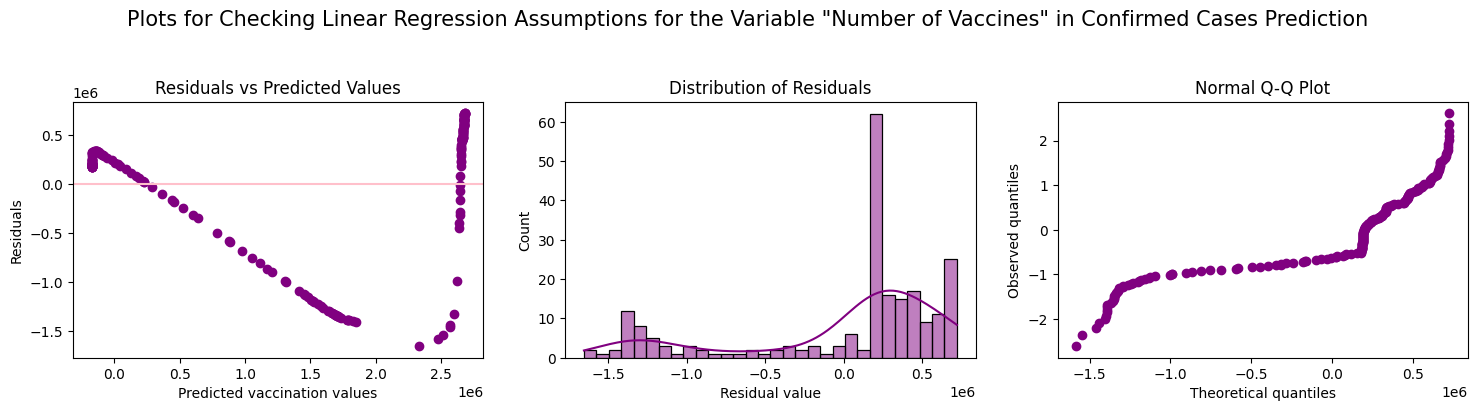

In [60]:
feat_1dim = df_denmark['vaccines']
X = np.matrix(feat_1dim).T.A
y_conf = df_denmark['confirmed']

X_train_conf_vacc, X_test_conf_vacc, y_train_conf_vacc, y_test_conf_vacc = train_test_split(
    X, y_conf, test_size=0.2, random_state=42
)

scaler = MinMaxScaler()
X_train_conf_vacc_sc = scaler.fit_transform(X_train_conf_vacc)
X_test_conf_vacc_sc = scaler.transform(X_test_conf_vacc)

lr_conf_vacc = LinearRegression()
lr_conf_vacc.fit(X_train_conf_vacc_sc, y_train_conf_vacc)
y_conf_pred_vacc = lr_conf_vacc.predict(X_test_conf_vacc_sc)

residual_conf_vacc = y_test_conf_vacc - y_conf_pred_vacc
x = np.sort(residual_conf_vacc)
y = norm.ppf(np.linspace(0, 1, len(x)))

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
plt.suptitle(
    'Plots for Checking Linear Regression Assumptions for the Variable "Number of Vaccines" in Confirmed Cases Prediction',
    fontsize=15
)
plt.subplots_adjust(top=0.75)

ax[0].scatter(y_conf_pred_vacc, residual_conf_vacc, color='purple')
ax[0].set_title('Residuals vs Predicted Values')
ax[0].set_xlabel('Predicted vaccination values')
ax[0].set_ylabel('Residuals')
ax[0].axhline(y=0, color='pink')

sns.histplot(residual_conf_vacc, kde=True, bins=30, ax=ax[1], color='purple')
ax[1].set_title('Distribution of Residuals')
ax[1].set_xlabel('Residual value')
ax[1].set_ylabel('Count')

ax[2].scatter(x, y, color='purple')
ax[2].set_title('Normal Q-Q Plot')
ax[2].set_xlabel('Theoretical quantiles')
ax[2].set_ylabel('Observed quantiles')

In [61]:
df_denmark=df_denmark.drop('date',axis=1)

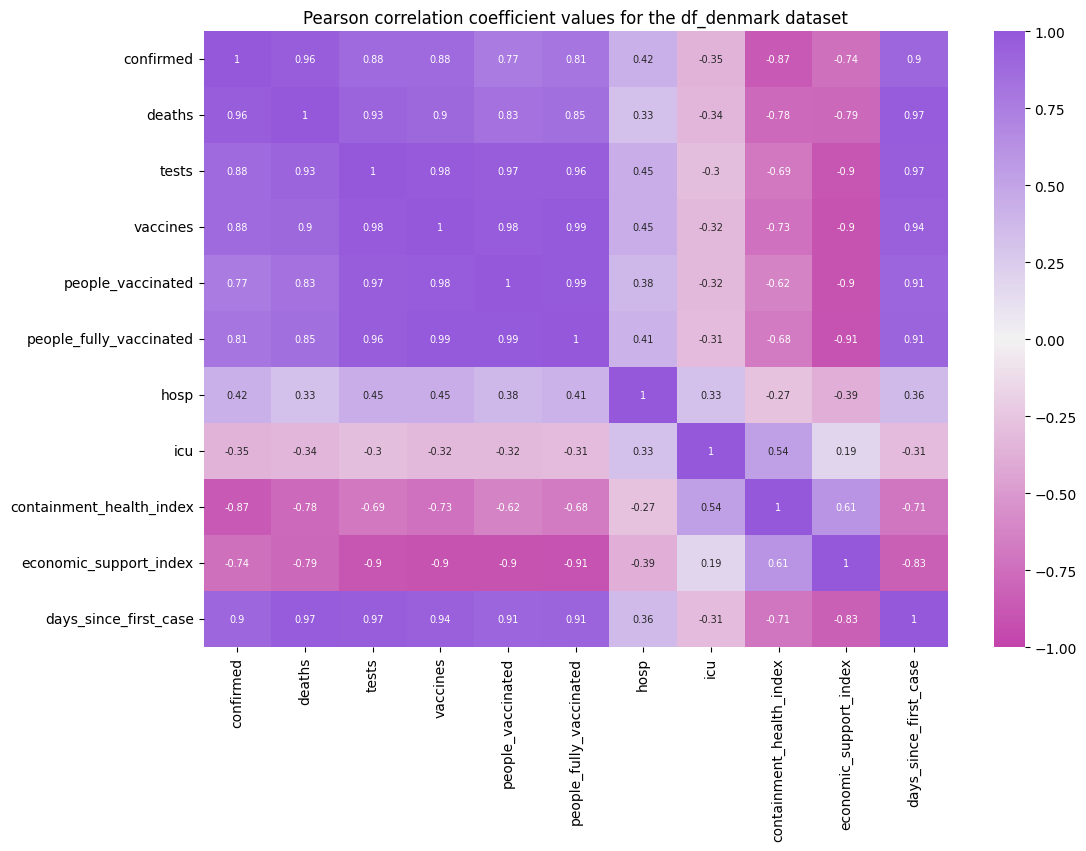

In [62]:
correlation_matrix=df_denmark.corr(method='pearson')

plt.figure(figsize=(12, 8))
cmap=sns.diverging_palette(320, 280, as_cmap=True)
sns.heatmap(correlation_matrix, annot=True, annot_kws={"size": 7}, cmap=cmap,vmax=1, vmin= -1)
plt.title('Pearson correlation coefficient values for the df_denmark dataset')
plt.show()

In [63]:
X_conf=df_denmark[['tests', 'vaccines','people_vaccinated', 'people_fully_vaccinated', 'containment_health_index', 'economic_support_index','days_since_first_case']]
X_death=df_denmark[['tests', 'vaccines','people_vaccinated', 'people_fully_vaccinated', 'hosp', 'icu', 'containment_health_index', 'economic_support_index','days_since_first_case']]
y_conf=df_denmark['confirmed']
y_death=df_denmark['deaths']

X_train_conf, X_test_conf, y_train_conf, y_test_conf=train_test_split(X_conf,y_conf,test_size=0.2,random_state=42)
X_train_death, X_test_death, y_train_death, y_test_death=train_test_split(X_death,y_death,test_size=0.2,random_state=42)

scaler=MinMaxScaler()
X_train_conf_sc=scaler.fit_transform(X_train_conf)
X_test_conf_sc=scaler.transform(X_test_conf)
X_train_death_sc=scaler.fit_transform(X_train_death)
X_test_death_sc=scaler.transform(X_test_death)

lr_conf=LinearRegression()
lr_conf.fit(X_train_conf_sc, y_train_conf)
y_conf_pred=lr_conf.predict(X_test_conf_sc)
mse_conf=mean_squared_error(y_test_conf, y_conf_pred)
rmse_conf=np.sqrt(mse_conf)
mae_conf=mean_absolute_error(y_test_conf,y_conf_pred)
r2_conf=r2_score(y_test_conf, y_conf_pred)

lr_death=LinearRegression()
lr_death.fit(X_train_death_sc, y_train_death)
y_death_pred=lr_death.predict(X_test_death_sc)
mse_death=mean_squared_error(y_test_death, y_death_pred)
rmse_death=np.sqrt(mse_death)
mae_death=mean_absolute_error(y_test_death,y_death_pred)
r2_death=r2_score(y_test_death, y_death_pred)

residual_conf_mult=y_test_conf-y_conf_pred
residual_death_mult=y_test_death-y_death_pred

confirmed_df=pd.DataFrame({'Predicted_variable': 'CONFIRMED', 'MSE': [mse_conf], 'RMSE': [rmse_conf], 'MAE': [mae_conf], 'R2': [r2_conf]})
death_df=pd.DataFrame({'Predicted_variable': 'DEATHS', 'MSE': [mse_death], 'RMSE': [rmse_death], 'MAE': [mae_death], 'R2': [r2_death]})
df_regression=pd.concat([confirmed_df,death_df],axis=0)
df_regression=df_regression.reset_index()
df_regression=df_regression.drop('index',axis=1)
df_regression

,Predicted_variable,MSE,RMSE,MAE,R2
0,CONFIRMED,4.744371e+10,217815.765414,164836.606161,0.976813
1,DEATHS,1.189350e+05,344.869548,267.786738,0.981853


<Axes: title={'center': 'R2'}, xlabel='Variables', ylabel='R2'>

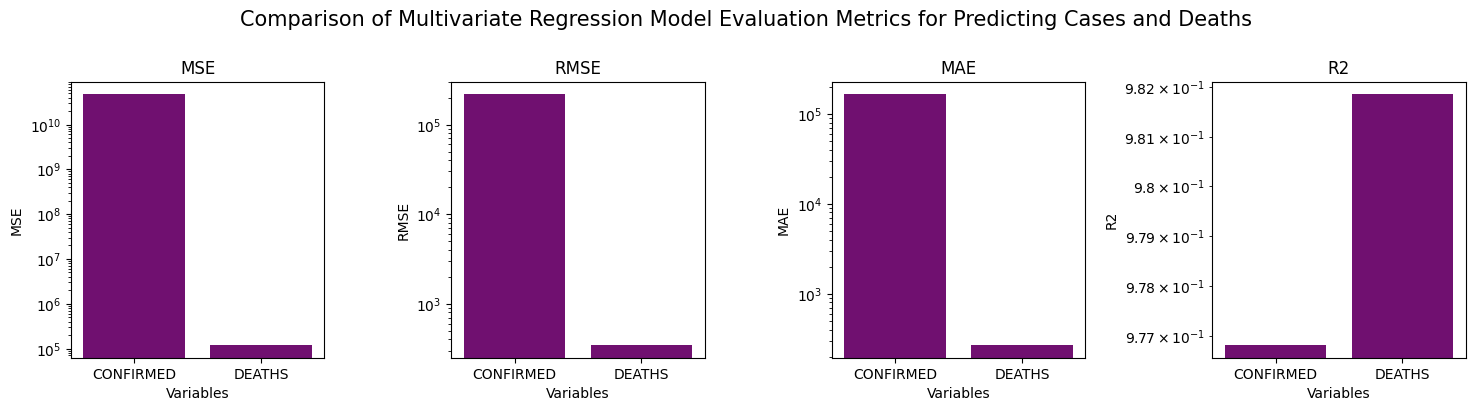

In [64]:
fig, ax = plt.subplots(1, 4, figsize=(18, 4))
plt.subplots_adjust(wspace=0.5, top=0.8)

plt.suptitle(
    'Comparison of Multivariate Regression Model Evaluation Metrics for Predicting Cases and Deaths',
    fontsize=15
)

ax[0].set_yscale('log')
ax[0].set_xlabel('Variables')
ax[0].set_title('MSE')
sns.barplot(x=df_regression['Predicted_variable'], y=df_regression['MSE'], ax=ax[0], color='purple')

ax[1].set_yscale('log')
ax[1].set_xlabel('Variables')
ax[1].set_title('RMSE')
sns.barplot(x=df_regression['Predicted_variable'], y=df_regression['RMSE'], ax=ax[1], color='purple')

ax[2].set_yscale('log')
ax[2].set_xlabel('Variables')
ax[2].set_title('MAE')
sns.barplot(x=df_regression['Predicted_variable'], y=df_regression['MAE'], ax=ax[2], color='purple')

ax[3].set_yscale('log')
ax[3].set_xlabel('Variables')
ax[3].set_title('R2')
sns.barplot(x=df_regression['Predicted_variable'], y=df_regression['R2'], ax=ax[3], color='purple')

In [65]:
results_conf_best=results_conf[results_conf['Feature']=='vaccines']
results_conf_best=results_conf_best.rename(columns={'Feature': 'Predicted_variable'})
results_death_best=results_death[results_death['Feature']=='days_since_first_case']
results_death_best=results_death_best.rename(columns={'Feature': 'Predicted_variable'})
results_conf_best['Predicted_variable']='CONFIRMED'
results_death_best['Predicted_variable']='DEATHS'
df_regression_compare=pd.concat([results_conf_best,results_death_best,df_regression],axis=0)
df_regression_compare=df_regression_compare.reset_index()
df_regression_compare=df_regression_compare.drop('index',axis=1)
regression_type=['linear regression for vaccines', 'linear regression for days_since_first_case','multiple regression', 'multiplle regression']
df_regression_compare.insert(0,'Regression type', regression_type)
df_regression_compare['y_pred']=[y_conf_pred_vacc,y_pred_death_days,y_conf_pred,y_death_pred]
df_regression_compare['y_test']=[y_test_conf_vacc,y_test_death_days,y_test_conf,y_test_death]
df_regression_compare['residuals']=[residual_conf_vacc,residual_death_days,residual_conf_mult,residual_death_mult]
df_regression_compare

,Regression type,Predicted_variable,MSE,RMSE,MAE,R2,y_pred,y_test,residuals
0,linear regression for vaccines,CONFIRMED,4.339991e+11,658786.046853,522076.937050,0.787890,"[1781972.023420414, 2678555.5971358763, -17580...",614 391221.0 974 3332764.0 56 80...,614 -1.390751e+06 974 6.542084e+05 56 ...
1,linear regression for days_since_first_case,DEATHS,3.909911e+05,625.292839,540.168417,0.940344,"[4011.914770456286, 6905.511449990605, -473.16...",614 2716.0 974 7321.0 56 394.0 665 ...,614 -1295.914770 974 415.488550 56 ...
2,multiple regression,CONFIRMED,4.744371e+10,217815.765414,164836.606161,0.976813,"[633513.7744394856, 3212193.4833897916, -42495...",614 391221.0 974 3332764.0 56 80...,614 -242292.774439 974 120570.516610 56 ...
3,multiplle regression,DEATHS,1.189350e+05,344.869548,267.786738,0.981853,"[2971.6738182338236, 7147.888168587813, -363.5...",614 2716.0 974 7321.0 56 394.0 665 ...,614 -255.673818 974 173.111831 56 757...


In [66]:
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

In [67]:
X_conf=df_denmark[['tests', 'vaccines','people_vaccinated', 'people_fully_vaccinated', 'containment_health_index', 'economic_support_index','days_since_first_case']]
X_death=df_denmark[['tests', 'vaccines','people_vaccinated', 'people_fully_vaccinated', 'hosp', 'icu', 'containment_health_index', 'economic_support_index','days_since_first_case']]
y_conf=df_denmark['confirmed']
y_death=df_denmark['deaths']

def regression_models(model, X, y):
  X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)

  scaler=MinMaxScaler()
  X_train_sc=scaler.fit_transform(X_train)
  X_test_sc=scaler.transform(X_test)

  model.fit(X_train_sc, y_train)
  y_pred=model.predict(X_test_sc)
  mse=mean_squared_error(y_test, y_pred)
  rmse=np.sqrt(mse)
  mae=mean_absolute_error(y_test,y_pred)
  r2=r2_score(y_test, y_pred)

  return mse, rmse, mae, r2, y_pred, y_test

In [68]:
models={'SVR': SVR(),'DecisionTree': DecisionTreeRegressor(),'RandomForest': RandomForestRegressor()}
datasets={'CONFIRMED': (X_conf, y_conf),'DEATHS': (X_death, y_death)}

In [69]:
results=[]
for model_name, model in models.items():
    for dataset_name, (X,y) in datasets.items():
        mse, rmse, mae, r2, y_pred, y_test=regression_models(model, X, y)
        results.append({
            'Regression_model': model_name,
            'Predicted_variable': dataset_name,
            'MSE': mse,
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2,
            'y_pred': y_pred,
            'y_test': y_test,
            'residuals': y_test-y_pred
        })
df_results = pd.DataFrame(results)
df_results

,Regression_model,Predicted_variable,MSE,RMSE,MAE,R2,y_pred,y_test,residuals
0,SVR,CONFIRMED,2.884829e+12,1.698478e+06,1.144947e+06,-0.409911,"[352407.9203593931, 352510.1689055983, 351828....",614 391221.0 974 3332764.0 56 80...,614 3.881308e+04 974 2.980254e+06 56 ...
1,SVR,DEATHS,6.130331e+06,2.475950e+03,1.884674e+03,0.064652,"[2807.4493543888298, 2921.635008493204, 2398.1...",614 2716.0 974 7321.0 56 394.0 665 ...,614 -91.449354 974 4399.364992 56 -2...
2,DecisionTree,CONFIRMED,8.759000e+07,9.358953e+03,3.374230e+03,0.999957,"[389240.0, 3332764.0, 7912.0, 685036.0, 293094...",614 391221.0 974 3332764.0 56 80...,614 1981.0 974 0.0 56 161.0 6...
3,DecisionTree,DEATHS,2.988649e+02,1.728771e+01,9.549550e+00,0.999954,"[2716.0, 7321.0, 403.0, 3187.0, 2533.0, 3394.0...",614 2716.0 974 7321.0 56 394.0 665 ...,614 0.0 974 0.0 56 -9.0 665 -14....
4,RandomForest,CONFIRMED,2.003272e+07,4.475793e+03,1.327874e+03,0.999990,"[389783.56, 3332741.39, 7990.82, 682190.08, 29...",614 391221.0 974 3332764.0 56 80...,614 1437.44 974 22.61 56 82.18 6...
5,RandomForest,DEATHS,1.167185e+02,1.080363e+01,5.285405e+00,0.999982,"[2716.9, 7320.21, 391.39, 3183.55, 2532.37, 33...",614 2716.0 974 7321.0 56 394.0 665 ...,614 -0.90 974 0.79 56 2.61 665 -...


In [70]:
df_regression_compare

,Regression type,Predicted_variable,MSE,RMSE,MAE,R2,y_pred,y_test,residuals
0,linear regression for vaccines,CONFIRMED,4.339991e+11,658786.046853,522076.937050,0.787890,"[1781972.023420414, 2678555.5971358763, -17580...",614 391221.0 974 3332764.0 56 80...,614 -1.390751e+06 974 6.542084e+05 56 ...
1,linear regression for days_since_first_case,DEATHS,3.909911e+05,625.292839,540.168417,0.940344,"[4011.914770456286, 6905.511449990605, -473.16...",614 2716.0 974 7321.0 56 394.0 665 ...,614 -1295.914770 974 415.488550 56 ...
2,multiple regression,CONFIRMED,4.744371e+10,217815.765414,164836.606161,0.976813,"[633513.7744394856, 3212193.4833897916, -42495...",614 391221.0 974 3332764.0 56 80...,614 -242292.774439 974 120570.516610 56 ...
3,multiplle regression,DEATHS,1.189350e+05,344.869548,267.786738,0.981853,"[2971.6738182338236, 7147.888168587813, -363.5...",614 2716.0 974 7321.0 56 394.0 665 ...,614 -255.673818 974 173.111831 56 757...


In [71]:
df_regression_compare=df_regression_compare.rename(columns={'Regression type': 'Regression_model'})
df_regressions=pd.concat([df_regression_compare,df_results],axis=0)
df_regressions=df_regressions.reset_index()
df_regressions=df_regressions.drop('index',axis=1)
df_regressions['Regression_model']=['LinearRegression for vaccines','LinearRegression for days_since_first_case', 'MultipleRegression', 'MultipleRegression','SVR', 'SVR',
                                    'DecisionTree','DecisionTree','RandomForest','RandomForest']
df_regressions

,Regression_model,Predicted_variable,MSE,RMSE,MAE,R2,y_pred,y_test,residuals
0,LinearRegression for vaccines,CONFIRMED,4.339991e+11,6.587860e+05,5.220769e+05,0.787890,"[1781972.023420414, 2678555.5971358763, -17580...",614 391221.0 974 3332764.0 56 80...,614 -1.390751e+06 974 6.542084e+05 56 ...
1,LinearRegression for days_since_first_case,DEATHS,3.909911e+05,6.252928e+02,5.401684e+02,0.940344,"[4011.914770456286, 6905.511449990605, -473.16...",614 2716.0 974 7321.0 56 394.0 665 ...,614 -1295.914770 974 415.488550 56 ...
2,MultipleRegression,CONFIRMED,4.744371e+10,2.178158e+05,1.648366e+05,0.976813,"[633513.7744394856, 3212193.4833897916, -42495...",614 391221.0 974 3332764.0 56 80...,614 -242292.774439 974 120570.516610 56 ...
3,MultipleRegression,DEATHS,1.189350e+05,3.448695e+02,2.677867e+02,0.981853,"[2971.6738182338236, 7147.888168587813, -363.5...",614 2716.0 974 7321.0 56 394.0 665 ...,614 -255.673818 974 173.111831 56 757...
4,SVR,CONFIRMED,2.884829e+12,1.698478e+06,1.144947e+06,-0.409911,"[352407.9203593931, 352510.1689055983, 351828....",614 391221.0 974 3332764.0 56 80...,614 3.881308e+04 974 2.980254e+06 56 ...
5,SVR,DEATHS,6.130331e+06,2.475950e+03,1.884674e+03,0.064652,"[2807.4493543888298, 2921.635008493204, 2398.1...",614 2716.0 974 7321.0 56 394.0 665 ...,614 -91.449354 974 4399.364992 56 -2...
6,DecisionTree,CONFIRMED,8.759000e+07,9.358953e+03,3.374230e+03,0.999957,"[389240.0, 3332764.0, 7912.0, 685036.0, 293094...",614 391221.0 974 3332764.0 56 80...,614 1981.0 974 0.0 56 161.0 6...
7,DecisionTree,DEATHS,2.988649e+02,1.728771e+01,9.549550e+00,0.999954,"[2716.0, 7321.0, 403.0, 3187.0, 2533.0, 3394.0...",614 2716.0 974 7321.0 56 394.0 665 ...,614 0.0 974 0.0 56 -9.0 665 -14....
8,RandomForest,CONFIRMED,2.003272e+07,4.475793e+03,1.327874e+03,0.999990,"[389783.56, 3332741.39, 7990.82, 682190.08, 29...",614 391221.0 974 3332764.0 56 80...,614 1437.44 974 22.61 56 82.18 6...
9,RandomForest,DEATHS,1.167185e+02,1.080363e+01,5.285405e+00,0.999982,"[2716.9, 7320.21, 391.39, 3183.55, 2532.37, 33...",614 2716.0 974 7321.0 56 394.0 665 ...,614 -0.90 974 0.79 56 2.61 665 -...


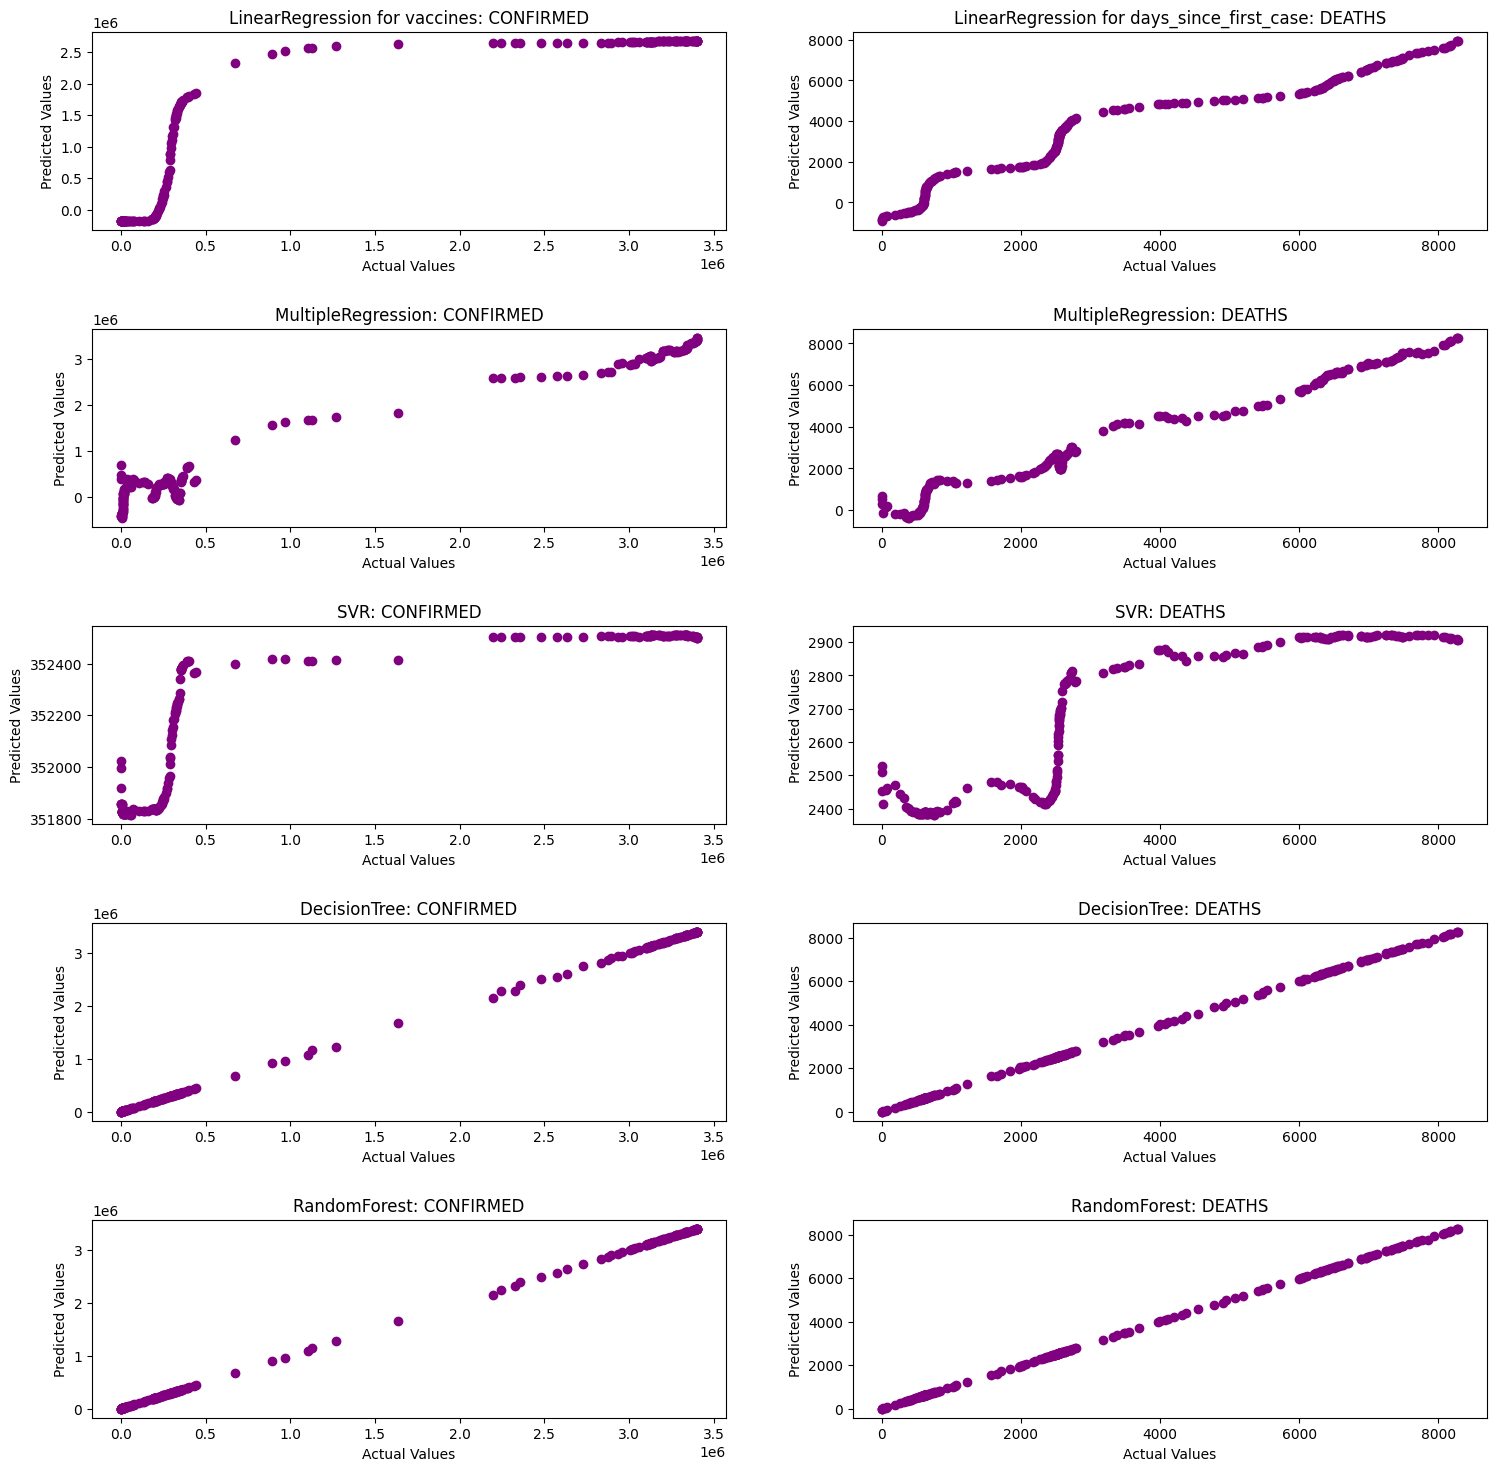

In [73]:
fig, ax = plt.subplots(5, 2, figsize=(18, 18))
plt.subplots_adjust(hspace=0.5)

for i in range(len(df_regressions)):
    row = i // 2
    col = i % 2
    ax[row, col].scatter(df_regressions['y_test'][i], df_regressions['y_pred'][i], color='purple')
    ax[row, col].set_title(f"{df_regressions['Regression_model'][i]}: {df_regressions['Predicted_variable'][i]}")
    ax[row, col].set_xlabel('Actual Values')
    ax[row, col].set_ylabel('Predicted Values')

plt.show()

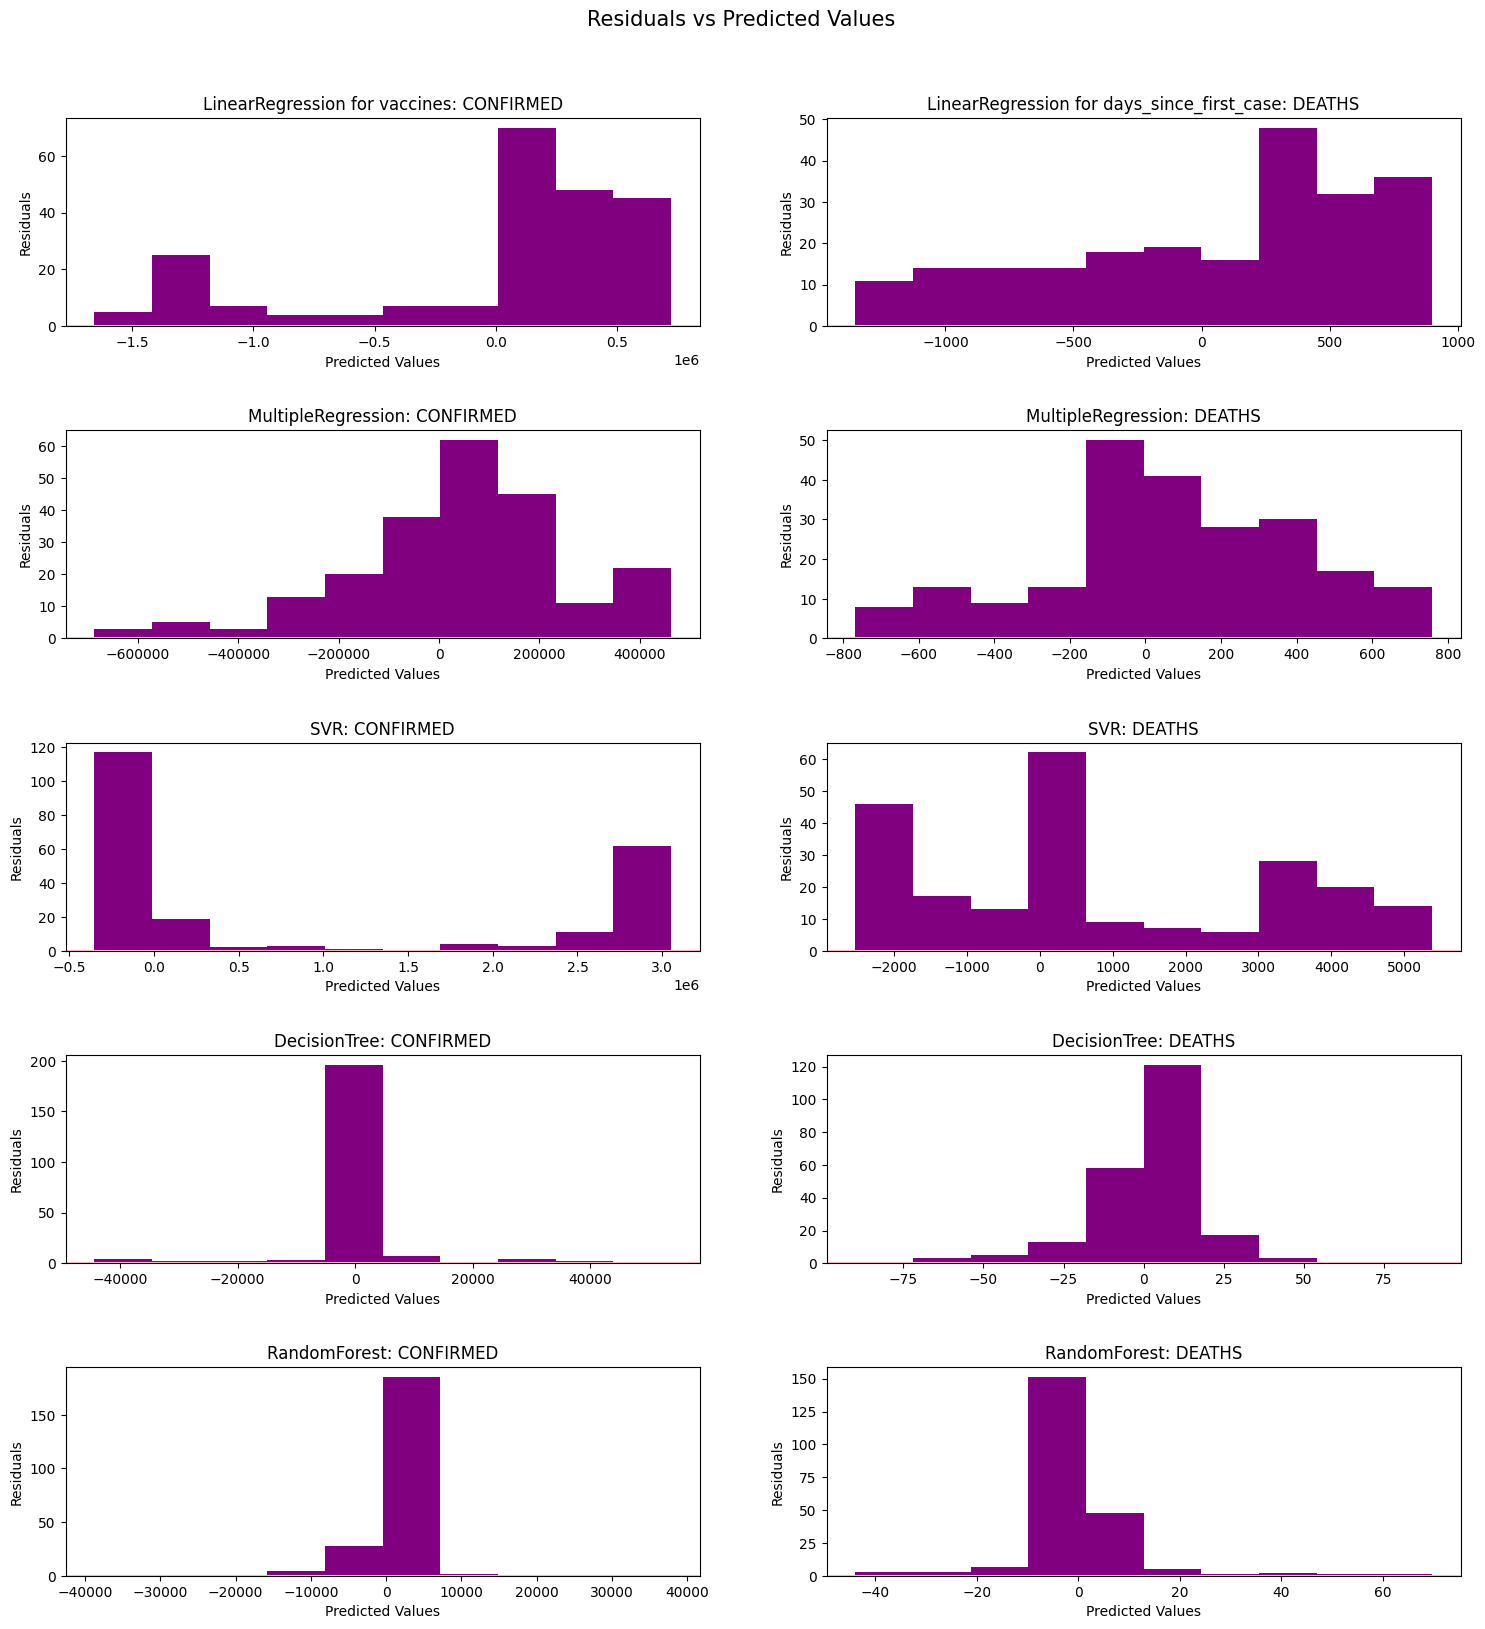

In [74]:
fig, ax = plt.subplots(5, 2, figsize=(18, 18))
plt.suptitle('Residuals vs Predicted Values', fontsize=15)
plt.subplots_adjust(hspace=0.5, top=0.92)

for i in range(len(df_regressions)):
    row = i // 2
    col = i % 2
    ax[row, col].hist(df_regressions['residuals'][i], color='purple')
    ax[row, col].set_title(f"{df_regressions['Regression_model'][i]}: {df_regressions['Predicted_variable'][i]}")
    ax[row, col].set_xlabel('Predicted Values')
    ax[row, col].set_ylabel('Residuals')
    ax[row, col].axhline(y=0, color='pink')

plt.show()